In [ ]:
!nvidia-smi

Mon Mar 29 22:23:32 2021       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 460.56       Driver Version: 460.32.03    CUDA Version: 11.2     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla T4            Off  | 00000000:00:04.0 Off |                    0 |
| N/A   45C    P8    10W /  70W |      0MiB / 15109MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

# Preparing Colab

## Installing pkgs

In [ ]:
!apt install tree neofetch
!neofetch

Reading package lists... Done
Building dependency tree       
Reading state information... Done
The following NEW packages will be installed:
  neofetch tree
0 upgraded, 2 newly installed, 0 to remove and 30 not upgraded.
Need to get 115 kB of archives.
After this operation, 470 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu bionic/universe amd64 neofetch all 3.4.0-1 [74.8 kB]
Get:2 http://archive.ubuntu.com/ubuntu bionic/universe amd64 tree amd64 1.7.0-5 [40.7 kB]
Fetched 115 kB in 1s (140 kB/s)
Selecting previously unselected package neofetch.
(Reading database ... 160980 files and directories currently installed.)
Preparing to unpack .../neofetch_3.4.0-1_all.deb ...
Unpacking neofetch (3.4.0-1) ...
Selecting previously unselected package tree.
Preparing to unpack .../tree_1.7.0-5_amd64.deb ...
Unpacking tree (1.7.0-5) ...
Setting up tree (1.7.0-5) ...
Setting up neofetch (3.4.0-1) ...
Processing triggers for man-db (2.8.3-2ubuntu0.1) ...
           

In [ ]:
!pip install --upgrade pip
!pip install albumentations==0.5.1
!pip install opencv-python==4.4.0.46
import cv2
cv2.__version__

     |████████████████████████████████| 1.5MB 8.5MB/s 
  Found existing installation: pip 19.3.1
    Uninstalling pip-19.3.1:
      Successfully uninstalled pip-19.3.1
     |████████████████████████████████| 71 kB 212 kB/s 
     |████████████████████████████████| 37.6 MB 7.9 kB/s 
     |████████████████████████████████| 948 kB 60.9 MB/s 
  Attempting uninstall: imgaug
    Found existing installation: imgaug 0.2.9
    Uninstalling imgaug-0.2.9:
      Successfully uninstalled imgaug-0.2.9
  Attempting uninstall: albumentations
    Found existing installation: albumentations 0.1.12
    Uninstalling albumentations-0.1.12:
      Successfully uninstalled albumentations-0.1.12
     |████████████████████████████████| 49.5 MB 41 kB/s 
  Attempting uninstall: opencv-python
    Found existing installation: opencv-python 4.1.2.30
    Uninstalling opencv-python-4.1.2.30:
      Successfully uninstalled opencv-python-4.1.2.30


'4.4.0'

In [ ]:
!pip install tensorflow kaggle sklearn nltk --upgrade 
!pip install -U tensorboard_plugin_profile 
cv2.__version__

     |████████████████████████████████| 58 kB 4.3 MB/s 
     |████████████████████████████████| 1.4 MB 13.6 MB/s 
  Created wheel for kaggle: filename=kaggle-1.5.12-py3-none-any.whl size=73053 sha256=fe9f6441ef22d6b855d5369802bea91c3d26d30c4c3c1edbc6d44142796c00c4
  Stored in directory: /root/.cache/pip/wheels/62/d6/58/5853130f941e75b2177d281eb7e44b4a98ed46dd155f556dc5
  Created wheel for nltk: filename=nltk-3.5-py3-none-any.whl size=1434678 sha256=9f4e8fd717001850f2e8e204275b89d06ac63aa1aa3b0e0bee2a128ec822e06e
  Stored in directory: /root/.cache/pip/wheels/45/6c/46/a1865e7ba706b3817f5d1b2ff7ce8996aabdd0d03d47ba0266
Successfully built kaggle nltk
  Attempting uninstall: nltk
    Found existing installation: nltk 3.2.5
    Uninstalling nltk-3.2.5:
      Successfully uninstalled nltk-3.2.5
  Attempting uninstall: kaggle
    Found existing installation: kaggle 1.5.10
    Uninstalling kaggle-1.5.10:
      Successfully uninstalled kaggle-1.5.10
     |████████████████████████████████| 1.2 M

'4.4.0'

## Mount DRIVE

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
# dirs
KAGGLE = "drive/My Drive/NRB_project/kaggle.json"
drive_data_dir = "drive/My Drive/NRB_project/"
table_dir = "drive/My Drive/NRB_project/table_blank.txt"


data_dir = "./data"
checks_dir = "./checkpoints"
csv_path = "./data/data.csv"
loading_dir = './CRNN_model/'
weights_dir = "drive/My Drive/NRB_project/CRNN"

In [ ]:
! mkdir ~/.kaggle
! mkdir ./data
! mkdir ./checkpoints

! cp "{table_dir}" "{data_dir}"

In [ ]:
!ls

checkpoints  data  drive  sample_data


In [ ]:
!ls "drive/My Drive/NRB_project/"

## Download Data

In [ ]:
! cp "{KAGGLE}" ~/.kaggle/
!kaggle datasets download -d tapakah68/yandextoloka-water-meters-dataset 

 99% 977M/982M [00:14<00:00, 77.8MB/s]
100% 982M/982M [00:14<00:00, 70.4MB/s]


In [ ]:
! unzip -q yandextoloka-water-meters-dataset.zip -d data # unzipping
!mv data/WaterMeters/* data/                             # moving files to /data
!rm -r data/WaterMeters/                                 # removing empty folder

In [ ]:
!ls "{data_dir}/"

collage  data.csv  images  masks  table_blank.txt


# Imports

In [ ]:
import os
import cv2
import pprint
import random
import pandas as pd
import tensorflow as tf
# import tensorflow_addons as tfa

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
%matplotlib inline

import albumentations as A
import math
import time
import nltk

from nltk.translate.bleu_score import sentence_bleu
from nltk.translate.bleu_score import SmoothingFunction as smoothier

def asHHMMSS(s):
    m = math.floor(s / 60)
    s -= m * 60
    h = math.floor(m / 60)
    m -= h * 60
    return '%dh:%dm:%ds'% (h, m, s)

from collections import Counter
from sklearn.model_selection import train_test_split

print(f"Albumentations v: {A.__version__}")
print(f"TensorFlow v: {tf.__version__}")
print(f"Opencv v: {cv2.__version__}")

f"Timing: {asHHMMSS(162)}"

Albumentations v: 0.5.1
TensorFlow v: 2.4.1
Opencv v: 4.4.0


'Timing: 0h:2m:42s'

## Hyperparameters

In [ ]:
SEED = 1234

IMAGES_path = os.path.join(data_dir, "images")
MASK_path = os.path.join(data_dir, "masks")
TABLE_path = os.path.join(data_dir, "table_blank.txt") 

# Extra functions

In [ ]:
def set_seeds(seed=SEED):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    tf.random.set_seed(seed)
    np.random.seed(seed)

def load_from_csv(path, delimiter=','):
    """
    Load csv file and return a NumPy array of its data

    Parameters
    ----------
    path: str
        The path to the csv file to load
    delimiter: str (default: ',')
        The csv field delimiter

    Return
    ------
    D: array
        The NumPy array of the data contained in the file
    """
    if not os.path.exists(path):
        raise FileNotFoundError(f"File '{path}' does not exists.")
    return pd.read_csv(path, delimiter=delimiter, engine='python')
    # return pd.read_csv(path, delimiter=delimiter, float_precision='high', encoding='utf-8' )#, engine='python')
    # return pd.read_excel(path, header=None, names=['mails'])

def visualize(colormap='viridis', figsize=(16, 7), title=None, colorbar=None, **images):
    """PLot images in one row."""
    n = len(images)
    plt.figure(figsize=figsize)
    # plt.figure(figsize=(16, 10))
    for i, (name, image) in enumerate(images.items()):
        plt.subplot(1, n, i + 1)
        plt.axis("off")
        if isinstance(image, list):
            plt.title(' '.join(name.split('_')).title() +": " + detokenize(image[1]), fontsize=16)        
            plt.imshow(image[0], cmap=colormap)
        if title:
            plt.title(title, fontsize=42)        
            plt.imshow(image, cmap=colormap) 
        else:
            plt.title(' '.join(name.split('_')).title(), fontsize=16)        
            plt.imshow(image, cmap=colormap)        
        if colorbar:
            plt.colorbar()
    plt.show()

# helper function for data visualization    
def denormalize(x, BGR_RGB=True):
    """Scale image to range 0..1 for correct plot"""
    x_max = np.percentile(x, 98)
    x_min = np.percentile(x, 2)    
    x = (x - x_min) / (x_max - x_min)
    x = x.clip(0, 1) 
    if BGR_RGB:
        x = cv2.cvtColor(x, cv2.COLOR_BGR2RGB)
    return x
def normalize_0_255(img):
    '''Return array with values in range [0, 255]'''    
    norm_image = cv2.normalize(np.float32(img), None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_32F)
    return norm_image.astype(np.uint8)

def crop_with_argwhere(image, mask):
    # https://codereview.stackexchange.com/questions/132914/crop-black-border-of-image-using-numpy
    # mask should has values > 0
    # Coordinates of non-black pixels.
    coords = np.argwhere(mask)
    # Bounding box of non-black pixels.
    x0, y0 = coords.min(axis=0)
    x1, y1 = coords.max(axis=0) + 1   # slices are exclusive at the top
    # Get the contents of the bounding box.
    cropped = image[x0:x1, y0:y1]
    return cropped

def create_crop_save_images(imgs_path, folder, color="RGB", kernel_sz=20
                            , apply_augmentation=False):
    '''Read, crop and save images'''
    images_fps = [os.path.join(IMAGES_path, image_id) for image_id in imgs_path]
    masks_fps = [os.path.join(MASK_path, image_id) for image_id in imgs_path] 
    to_dilate = True if kernel_sz else False

    folder2save = os.path.join(data_dir, folder)
    if not os.path.exists(folder2save):
        os.makedirs(folder2save)
    final_path = []
    counter = 0
    for i in range(len(images_fps)):
        # change extension from jpg to png 
        path2save = os.path.join(folder2save, imgs_path[i].rsplit('.',1)[0]+'.png')
        if path2save in final_path: 
            # do not overwrite images when data augment            
            path2save = path2save.replace("_v", "-2_v")
            counter +=1
        if color=="RGB":
            image = cv2.imread(images_fps[i])
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        elif color=="gray": # gray scale
            image = cv2.imread(images_fps[i], 0)   

        mask = cv2.imread(masks_fps[i], 0) # 0 = cv2.COLOR_GRAYSCALE  
        # if apply_augmentation: # here can also be include the MASK
        #     sample = apply_augmentation(image=image)
        #     image = sample['image']
                        
        image=cv2.bitwise_and(image, image, mask=mask)  # mask selection
        
        if to_dilate:
            kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (kernel_sz, kernel_sz))
            dilate = cv2.dilate(mask, kernel, iterations=3)
            image= crop_with_argwhere(image, dilate) # cropping to dilated size
            mask= crop_with_argwhere(mask, dilate)
        else:
            image = crop_with_argwhere(image, mask) # cropping to mask size
            mask = crop_with_argwhere(mask, mask)
        # apply alignment with the given mask
        # image = align_rotate(image=image, with_mask=mask)
        image = align_rotate(inputs=[image, mask] )
        if apply_augmentation: # here can also be include the MASK
            sample = apply_augmentation(image=image)
            image = sample['image']

        final_path.append(path2save)
        cv2.imwrite(path2save, cv2.cvtColor(image, cv2.COLOR_RGB2BGR))
    if counter: print("Repetitions:", counter)
    return final_path
# !rm -r data/train
# create_crop_save_images(X_valid[:3], "None", kernel_sz=None, apply_augmentation=get_training_augmentation())

In [ ]:
# taken from here: https://stackoverflow.com/questions/56459002/how-to-detect-and-align-tilted-images-after-cropping
def order_corner_points(corners):
    # Separate corners into individual points
    # Index 0 - top-right
    #       1 - top-left
    #       2 - bottom-left
    #       3 - bottom-right
    if len(corners) == 4:
        top_l, top_r, bottom_r, bottom_l = corners[2], corners[3], corners[0], \
                                           corners[1]
        return (top_l, top_r, bottom_r, bottom_l)
    corners = [(corner[0][0], corner[0][1]) for corner in corners]
    top_r, top_l, bottom_l, bottom_r = corners[0], corners[1], corners[2], \
                                       corners[3]
    return (top_l, top_r, bottom_r, bottom_l)

def perspective_transform(image, corners):
    # Order points in clockwise order
    ordered_corners = order_corner_points(corners)
    top_l, top_r, bottom_r, bottom_l = ordered_corners

    # Determine width of new image which is the max distance between
    # (bottom right and bottom left) or (top right and top left) x-coordinates
    width_A = np.sqrt(((bottom_r[0] - bottom_l[0]) ** 2) + (
                (bottom_r[1] - bottom_l[1]) ** 2))
    width_B = np.sqrt(
        ((top_r[0] - top_l[0]) ** 2) + ((top_r[1] - top_l[1]) ** 2))
    width = max(int(width_A), int(width_B))

    # Determine height of new image which is the max distance between
    # (top right and bottom right) or (top left and bottom left) y-coordinates
    height_A = np.sqrt(
        ((top_r[0] - bottom_r[0]) ** 2) + ((top_r[1] - bottom_r[1]) ** 2))
    height_B = np.sqrt(
        ((top_l[0] - bottom_l[0]) ** 2) + ((top_l[1] - bottom_l[1]) ** 2))
    height = max(int(height_A), int(height_B))

    # Construct new points to obtain top-down view of image in
    # top_r, top_l, bottom_l, bottom_r order
    dimensions = np.array([[0, 0], [width - 1, 0], [width - 1, height - 1],
                           [0, height - 1]], dtype="float32")

    # Convert to Numpy format
    ordered_corners = np.array(ordered_corners, dtype="float32")

    # Find perspective transform matrix
    matrix = cv2.getPerspectiveTransform(ordered_corners, dimensions)

    # Return the transformed image
    return cv2.warpPerspective(image, matrix, (width, height))

def get_image_width_height(image):
    image_width = image.shape[1]  # current image's width
    image_height = image.shape[0]  # current image's height
    return image_width, image_height

def calculate_scaled_dimension(scale, image):
    image_width, image_height = get_image_width_height(image)
    ratio_of_new_with_to_old = scale / image_width

    dimension = (scale, int(image_height * ratio_of_new_with_to_old))
    return dimension

def scale_image(image, size):
    image_resized_scaled = cv2.resize(
        image,
        calculate_scaled_dimension(
            size,
            image
        ),
        interpolation=cv2.INTER_AREA
    )
    return image_resized_scaled

def rotate_image(image, angle):
    # Grab the dimensions of the image and then determine the center
    (h, w) = image.shape[:2]
    (cX, cY) = (w / 2, h / 2)

    # grab the rotation matrix (applying the negative of the
    # angle to rotate clockwise), then grab the sine and cosine
    # (i.e., the rotation components of the matrix)
    M = cv2.getRotationMatrix2D((cX, cY), -angle, 1.0)
    cos = np.abs(M[0, 0])
    sin = np.abs(M[0, 1])

    # Compute the new bounding dimensions of the image
    nW = int((h * sin) + (w * cos))
    nH = int((h * cos) + (w * sin))

    # Adjust the rotation matrix to take into account translation
    M[0, 2] += (nW / 2) - cX
    M[1, 2] += (nH / 2) - cY

    # Perform the actual rotation and return the image
    return cv2.warpAffine(image, M, (nW, nH))

def align_rotate(inputs, to_plot=False, to_save=False, to_scale:int=None
                      , to_rotate=True, path2save=None):
    
    # if len(inputs) == 2:
    #     # copy original image to plot later if neded
    #     image, mask = inputs
    #     original_image = image.copy()        
    #     # mask = cv2.imread(with_mask, 0)
    # else:
    #     original_image = image.copy()
    # if to_scale:
    #     image = scale_image(image, to_scale)
    #     mask = scale_image(mask, to_scale) if len(inputs)==2 else None
    
    if len(inputs) != 2:
        original_image = inputs.copy()
        if to_scale:  # if you want to enlarge the image
            image = scale_image(inputs, to_scale)
        # convert the image to grayscale, blur it, and find edges in the image
        gray_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        # gray_rgb = cv2.bilateralFilter(gray_rgb, 11, 17, 17)
        # gray_rgb = cv2.medianBlur(gray_rgb, 7) # working
        # gray_rgb = cv2.medianBlur(gray_rgb, 9) # working
        gray_rgb = cv2.medianBlur(gray_rgb, 5) # working too
        edged = cv2.Canny(gray_rgb, 30, 200)  # edges
        # edged = cv2.Canny(gray_rgb, 30, 200, L2gradient=True, apertureSize=3)  # edges
    else:
        image, mask = inputs
        original_image = image.copy()   
        if to_scale: # if you want to enlarge the image
            image = scale_image(image, to_scale)
            mask = scale_image(mask, to_scale)
        mask = cv2.medianBlur(mask, 5)
        edged = cv2.Canny(mask, 30, 200)
    # search for contours | returns contours and hierarchy of them
    cnts = cv2.findContours(edged.copy(), cv2.RETR_TREE,
                            cv2.CHAIN_APPROX_SIMPLE)
    cnts = cnts[0] if len(cnts) == 2 else cnts[1]  # drops the hierarchy
    # sort them by area from higher to lower size | picks the top10
    cnts = sorted(cnts, key=cv2.contourArea, reverse=True)[:10]

    img_contours = image.copy()
    # loop through the contours and apply perspective transform
    for idx in range(len(cnts)):
        cv2.drawContours(img_contours, cnts, idx, (0, 255, 0), 1)
        # find minimal rectangle for the contour
        rect = cv2.minAreaRect(cnts[idx])
        box = cv2.boxPoints(rect)
        box = np.int0(box)
        # change perspective of the rectangle in the image
        transformed = perspective_transform(image, box)
        break

    if to_rotate:
        # rotate if necessary
        (h, w) = transformed.shape[:2]        
        if (h > w):
            rotated = rotate_image(transformed, 90)
        else:
            rotated = transformed

        return rotated
    if to_plot:
        cv2.namedWindow("image", cv2.WINDOW_NORMAL)
        cv2.namedWindow("transformed", cv2.WINDOW_NORMAL)
        cv2.namedWindow("contours", cv2.WINDOW_NORMAL)
        if to_rotate:
            cv2.namedWindow("rotated", cv2.WINDOW_NORMAL)
            cv2.imshow("rotated", rotated)
        cv2.imshow("transformed", transformed)
        cv2.imshow("image", original_image)
        cv2.imshow("contours", img_contours)
        cv2.waitKey(0)
    if to_save:
        cv2.imwrite(os.path.join("aligned", path2save), rotated)
    return transformed

## Augmentation & Preprocessing

In [ ]:
# # Declare an augmentation pipeline
# transform = A.Compose([
    
#     # A.HorizontalFlip(p=0.5),
#     # A.RandomBrightnessContrast(p=0.9),
#     # A.OpticalDistortion(p=1., distort_limit=0.55, shift_limit=0.05, border_mode=0 )
#     # A.IAAEmboss(p=1),
#     # A.CLAHE(p=1),
    
#     A.HueSaturationValue(p=1),
#     A.RandomContrast(p=1),
#     # A.RandomBrightness(p=1, limit=(-0.1, 0.5)),
#     # A.RandomBrightness(p=1, limit=(-0.1,0.3)),
#     # A.RandomGamma(p=1),
#     # A.MultiplicativeNoise(multiplier=[0.5, 1.5], elementwise=True, per_channel=True, p=1), # useful need to check
#     # A.MultiplicativeNoise(multiplier=[.5, 1.5], per_channel=True, p=1), # useful 
#     # A.MultiplicativeNoise(multiplier=[.5, 2.5], elementwise=True, p=1), # useful need to check
#     # A.MultiplicativeNoise(multiplier=[.5, 2.5], elementwise=True, p=1), # useful need to check
    
#     # A.Cutout(num_holes=35, max_h_size=10, max_w_size=10, fill_value=0, p=1),
#     # A.JpegCompression(quality_lower=19, quality_upper=20, p=1), # useful

#     # A.ChannelShuffle(p=1) # nope
#     # nopes
#     # A.MotionBlur(blur_limit=5, p=1),
#     # A.MedianBlur(blur_limit=7, p=1.),
#     # A.IAASharpen(p=1),
#     # A.Rotate(limit=5, p=0.93, border_mode=0),

# ])

# # Read an image with OpenCV and convert it to the RGB colorspace
# image = cv2.imread("data/valid/id_852_value_106_791.png")
# image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# # transform = get_training_augmentation()
# # Augment an image

# # transformed = get_training_augmentation()(image=image)
# # transformed = transform(image=transformed["image"])
# for image in dds:
#     transformed = transform(image=image)
#     transformed_image = transformed["image"]

#     visualize(image=image, #)
#     # visualize(    
#         transformed=transformed_image
#     )
#     transformed_image.shape

In [ ]:
# dds = []
# for _ in range(3):
#     for i in X_cut_valid[:7]:

#         img = cv2.imread(i)
#         img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
#         dds.append(img)
#         transformed = get_training_augmentation()(image=img)["image"]

#         visualize(  original=img,
#                     augmented=transformed
#                 )

In [ ]:
def round_clip_0_1(x, **kwargs):
    return x.round().clip(0, 1)

def get_training_augmentation():
    train_transform = [
        
        # A.ShiftScaleRotate(p=.5, border_mode=0, 
        #                     rotate_limit=15,),

        # A.PadIfNeeded(min_height=320, min_width=320, 
        #               always_apply=True, border_mode=0),

        # A.CenterCrop (height=320, width=320, always_apply=True),
        # A.RandomCrop(height=320, width=320, always_apply=True),
        # A.CropNonEmptyMaskIfExists (height=320, width=320, always_apply=True),
         

        A.OneOf( # problem `HueSaturationValue` does not work for gray images
            [
                A.RandomContrast(p=1),
                A.HueSaturationValue(p=1),
            ],
            p=0.667,
            # # p=0.7667,
            # p=1,
        ),

        A.OneOf(
            [
                A.CLAHE(p=1),
                A.RandomBrightness(p=1, limit=(-0.1, 0.3)),
                # A.RandomGamma(p=1),
            ],
            # p=0.667,
            p=0.7667,
            # p=1,
        ),

        A.OneOf(
            [
                A.IAASharpen(p=1),
                A.Blur(blur_limit=5, p=1),
                A.MotionBlur(blur_limit=5, p=1),
            ],
            # # p=0.667,
            p=0.7667,
            # p=1,
        ),
        # # ------------------
        A.OneOf(
            [
        A.MultiplicativeNoise(multiplier=[.5, 1.5], elementwise=False, p=1),
        A.JpegCompression(quality_lower=26, quality_upper=27, p=1),
            ],
            p=0.667
            # p=1
        ),        
        # A.Cutout(num_holes=20, max_h_size=5, max_w_size=5, fill_value=0, p=0.33), # does not work
        # ------------------
        A.Rotate(limit=5, p=0.33, border_mode=0),
        # A.Rotate(limit=5, p=0.37, border_mode=0),
        A.Lambda(mask=round_clip_0_1),
    ]
    return A.Compose(train_transform)

def preprocess_data_input(image=None, mask=None, **kwargs):
    """Preprocess Images according to `ImageNet`
    Args:
        image: image to process
        mask: mask of the image
        kwargs: inserted to not break the convention of 
                albumentations.Compose
    Return:
        function from keras that process the image.    
    """
    return tf.keras.applications.imagenet_utils.preprocess_input(image.copy(), mode="caffe")

def get_validation_augmentation():
    """Add paddings to make image shape divisible by 32"""
    test_transform = [
        # A.PadIfNeeded(384, 480)
        # A.PadIfNeeded(min_height=320, min_width=320, 
        #               always_apply=True, border_mode=0),
        A.Rotate(limit=5, p=1.0)
    ]
    return A.Compose(test_transform)

def get_preprocessing(preprocessing_fn):
    """Construct preprocessing transform
    
    Args:
        preprocessing_fn (callbale): data normalization function 
            (can be specific for each pretrained neural network)
    Return:
        transform: albumentations.Compose
    
    """    
    _transform = [
        A.Lambda(image=preprocessing_fn),
    ]
    return A.Compose(_transform)

# DATA

In [ ]:
# def padding_train_sequences(seqs, max_length, padding_type="post"):
#     vector = tf.keras.preprocessing.sequence.pad_sequences(seqs, padding=padding_type, maxlen=max_length)
#     return vector

def grab_value_from_name(sentence, sep="."):
    '''Function to grab the actual value from image name; due to problems in the CSV file.'''
    start, end = "value_", ".jpg"
    return sentence[sentence.find(start)+len(start) : sentence.rfind(end)].replace("_", sep)
    # return sentence[sentence.find(start)+len(start) : sentence.rfind(end)].split("_")[0]


def plot_occurrences(values, per_posi=None, remove=None):
    vals = [v for value in values for v in value]
    vocab_count = Counter(vals)


    fig = plt.figure(figsize = (13, 7)) 
    ctr = 0
    tab_vals = ['.', '0', '1','2','3','4','5','6','7','8','9']
    if remove: tab_vals.remove(remove)
    for i in tab_vals:
        if per_posi is not None:
            previous = 0
            for key, val in per_posi[i].items():
                col = cm.nipy_spectral( float(key) / 9)
                plt.bar(i, val, bottom=previous, color=col)
                previous= previous + val
        else:
            plt.bar(i, vocab_count[i], color='lightblue')
        plt.annotate(f"{vocab_count[i]}",
                     xy= (ctr , vocab_count[i] + 8),
                     ha='center', va='bottom', fontsize=12
        )
        ctr+=1

    plt.grid(alpha=.4)
    # plt.title("Ocurrences per token",  fontsize=18)
    plt.ylabel("Number of occurrences", fontsize=14)
    plt.xlabel("Tokens", fontsize=14)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    if per_posi is not None:
        plt.legend([f'{n}-position' for n in range(1,10)], fontsize=14)

def get_perPosition(labels):
    per_position = {}.fromkeys(['.', '0', '1','2','3','4','5','6','7','8','9'], {}.fromkeys([str(i) for i in range( 9)], 0))
    per_position = pd.DataFrame.from_dict(per_position)
    for label in labels:
        for idx in range(len(label)):
            per_position[label[idx]][str(idx)] += 1
    return per_position

def pad_labels(labels, sep="."):
    padded_labels = []
    # max_l = max(len(lbl) for lbl in labels)
    max_left = max(len(lbl.split(sep)[0] ) for lbl in labels)
    max_right = max(len(lbl.split(sep)[1]) for lbl in labels)
    ctr_left, ctr_lo, ctr_sht = 0,0,0
    sh_r_nbs, lo_r_nbs = [], []
    for lab in labels:
        _fill_left = max_left - len(lab.split(sep)[0])
        if _fill_left > 0: # count left side of the sequence
            ctr_left+=1
        _fill_right = max_right - len(lab.split(sep)[1])
        if _fill_right < 2 and _fill_right is not 0: # filling less 0 means, long seqs
            lo_r_nbs.append((labels.index(lab), lab))
            ctr_lo+=1
        elif _fill_right > 1: # short sequences
            sh_r_nbs.append((labels.index(lab), lab))
            ctr_sht+=1
        lab = _fill_left * "0" + lab
        # lab = _fill_left * "0" + lab.replace(".", "") # remove the point keep everything
        lab = lab + "0"*_fill_right
        # padded_labels.append(lab.split(sep)[0] ) # break on sep and keep left side
        padded_labels.append(lab)
    print("Padded counts:",ctr_left, ctr_sht, ctr_lo)
    return padded_labels, sh_r_nbs, lo_r_nbs

# pad_labels(labels_noPad[:4]), labels_noPad[:4]
CSV = load_from_csv(csv_path)
print(CSV.head(10))

                  photo_name  ...                                           location
0    id_53_value_595_825.jpg  ...  {'type': 'polygon', 'data': [{'x': 0.30788, 'y...
1    id_553_value_65_475.jpg  ...  {'type': 'polygon', 'data': [{'x': 0.26133, 'y...
2     id_407_value_21_86.jpg  ...  {'type': 'polygon', 'data': [{'x': 0.27545, 'y...
3   id_252_value_313_322.jpg  ...  {'type': 'polygon', 'data': [{'x': 0.21967, 'y...
4   id_851_value_305_162.jpg  ...  {'type': 'polygon', 'data': [{'x': 0.06983, 'y...
5     id_398_value_8_898.jpg  ...  {'type': 'polygon', 'data': [{'x': 0.60781, 'y...
6   id_1204_value_78_677.jpg  ...  {'type': 'polygon', 'data': [{'x': 0.26854, 'y...
7   id_83_value_1336_114.jpg  ...  {'type': 'polygon', 'data': [{'x': 0.31447, 'y...
8  id_1061_value_572_883.jpg  ...  {'type': 'polygon', 'data': [{'x': 0.14358, 'y...
9     id_71_value_90_216.jpg  ...  {'type': 'polygon', 'data': [{'x': 0.30247, 'y...

[10 rows x 3 columns]


## Brief analysis of the data images

In [ ]:
X = CSV['photo_name'].tolist()
X.remove("id_664_value_45_2676.jpg") # remove image with the longest floats
X = np.array(X)

y = [grab_value_from_name(name, ".") for name in X]
labels_noPad = [grab_value_from_name(name, ".") for name in X] # raw labels
# labels = [grab_value_from_name(name, ".") for name in X] # raw labels
labels, short_r_seqs, long_r_seqs = pad_labels(labels_noPad)

print("Data shape:", X.shape, np.array(y).shape)

Padded counts: 1240 41 87
Data shape: (1243,) (1243,)


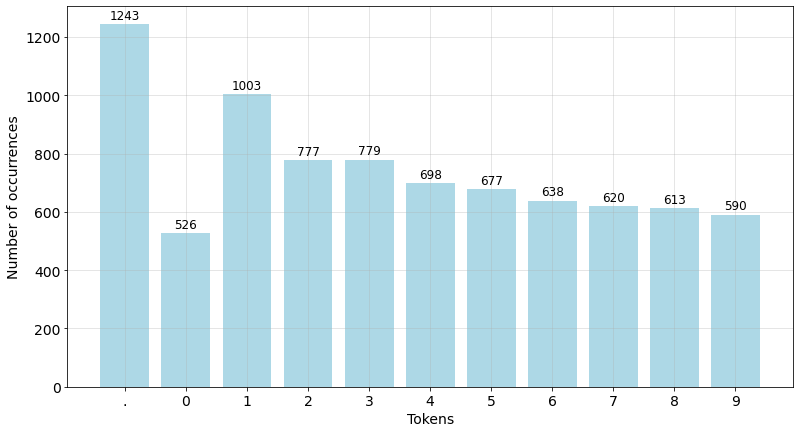

In [ ]:
plot_occurrences(y)  

In [ ]:
np.argmax([len(i) for i in y]), y[756]

(756, '99999.539')

In [ ]:
per_position = get_perPosition(labels)
per_position

,.,0,1,2,3,4,5,6,7,8,9
0,0,1240,1,0,0,1,0,0,0,0,1
1,0,1192,41,7,0,0,1,1,0,0,1
2,0,393,282,176,126,81,59,48,38,22,18
3,0,146,133,130,141,136,123,123,106,92,113
4,0,129,134,119,133,103,129,112,113,138,133
5,1243,0,0,0,0,0,0,0,0,0,0
6,0,154,134,115,139,140,121,115,106,129,90
7,0,167,135,112,117,108,125,120,126,127,106
8,0,128,143,118,123,129,119,119,131,105,128


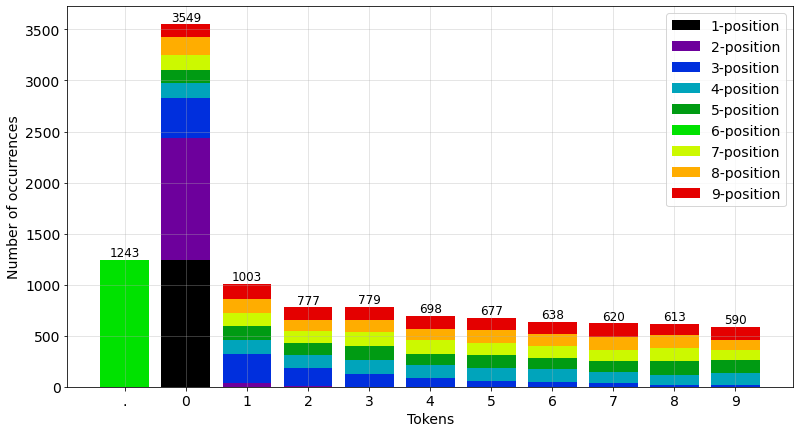

In [ ]:
plot_occurrences(labels, per_position)

In [ ]:
len(short_r_seqs), len(long_r_seqs)

(41, 87)

In [ ]:
def chunks(l, n):
    """Yield successive n-sized chunks from l."""
    for i in range(0, len(l), n):
        yield l[i:i + n]

def read_chunk(chunk):
    ids = [X[idx] for (idx, _) in chunk]
    images = [os.path.join("/content/data/images/", X[idx]) for (idx, _) in chunk]
    images = [cv2.imread(img) for img in images]
    images = [cv2.cvtColor(img, cv2.COLOR_BGR2RGB) for img in images]
    return images, ids

all_short_seqs = []
for batch in chunks(short_r_seqs, 6):
    images, ids = read_chunk(batch)
    ids = [id for id in ids if id.rsplit("_", 1)[1].startswith('0')]
    all_short_seqs.extend(ids)
    # visualize(
    #     image0=images[0],
    #     image1=images[1],
    #     image2=images[2],
    #     image3=images[3],
    #     image4=images[4],
    #     image5=images[5] if len(images)==6 else np.zeros(images[0].shape)
    #     , figsize=(30, 17)
    # )

In [ ]:
# list of all short sequences
len(all_short_seqs), all_short_seqs

(33,
 ['id_58_value_336_0.jpg',
  'id_419_value_1227_0.jpg',
  'id_996_value_19_0.jpg',
  'id_632_value_1369_0.jpg',
  'id_90_value_729_0.jpg',
  'id_251_value_36_0.jpg',
  'id_946_value_809_0.jpg',
  'id_647_value_1315_0.jpg',
  'id_986_value_748_0.jpg',
  'id_324_value_793_0.jpg',
  'id_488_value_134_0.jpg',
  'id_872_value_193_0.jpg',
  'id_249_value_706_0.jpg',
  'id_474_value_833_0.jpg',
  'id_1237_value_454_0.jpg',
  'id_509_value_156_0.jpg',
  'id_258_value_619_0.jpg',
  'id_566_value_258_0.jpg',
  'id_860_value_2693_0.jpg',
  'id_96_value_353_0.jpg',
  'id_1125_value_0_0.jpg',
  'id_415_value_262_0.jpg',
  'id_234_value_501_0.jpg',
  'id_839_value_1025_0.jpg',
  'id_45_value_215_0.jpg',
  'id_1011_value_567_0.jpg',
  'id_494_value_854_0.jpg',
  'id_874_value_509_0.jpg',
  'id_77_value_665_0.jpg',
  'id_630_value_164_0.jpg',
  'id_1234_value_850_0.jpg',
  'id_823_value_797_0.jpg',
  'id_1121_value_712_0.jpg'])

In [ ]:
for i in ['id_799_value_22_0.jpg', 'id_563_value_3_0.jpg', 'id_478_value_226_0.jpg']:
    all_short_seqs.remove(i) 

In [ ]:
for batch in chunks(all_short_seqs, 6):
    images = [os.path.join("/content/data/images/", ids) for ids in batch]
    images = [cv2.imread(img) for img in images]
    images = [cv2.cvtColor(img, cv2.COLOR_BGR2RGB) for img in images]
    visualize(
        image0=images[0],
        image1=images[1],
        image2=images[2],
        image3=images[3] if len(images)==6 else np.zeros(images[0].shape),
        image4=images[4] if len(images)==6 else np.zeros(images[0].shape),
        image5=images[5] if len(images)==6 else np.zeros(images[0].shape)
        , figsize=(30, 17)
    )

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
X = CSV['photo_name'].tolist()
# remove list of short sequences
before = len(X)
X.remove("id_664_value_45_2676.jpg") # remove image with the longest floats
for id in all_short_seqs:
    X.remove(id)
print(f"Data length before: {before}, after: {len(X)}")

X = np.array(X)

y = [grab_value_from_name(name, ".") for name in X]
labels_noPad = [grab_value_from_name(name, ".") for name in X] # raw labels
# labels = [grab_value_from_name(name, ".") for name in X] # raw labels
labels, short_r_seqs, long_r_seqs = pad_labels(labels_noPad)

print("Data shape:", X.shape, np.array(y).shape, np.array(labels).shape)

Data length before: 1244, after: 1210
Padded counts: 1207 8 87
Data shape: (1210,) (1210,) (1210,)


      .     0    1    2    3    4    5    6    7    8    9
0     0  1207    1    0    0    1    0    0    0    0    1
1     0  1164   37    6    0    0    1    1    0    0    1
2     0   389  278  172  122   80   56   45   32   18   18
3     0   141  128  127  137  135  117  118  106   92  109
4     0   127  133  117  128   99  125  108  110  136  127
5  1210     0    0    0    0    0    0    0    0    0    0
6     0   121  134  115  139  140  121  115  106  129   90
7     0   134  135  112  117  108  125  120  126  127  106
8     0    95  143  118  123  129  119  119  131  105  128


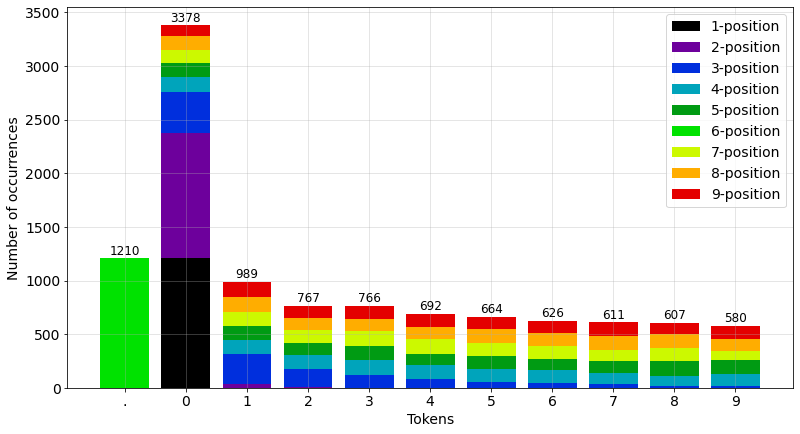

In [ ]:
newPosition = get_perPosition(labels)
print(newPosition)
plot_occurrences(labels, newPosition)

In [ ]:

for batch in chunks(long_r_seqs, 6):
    images, ids = read_chunk(batch)
    visualize(
        image0=images[0],
        image1=images[1],
        image2=images[2],
        image3=images[3] if len(images)==6 else np.zeros(images[0].shape),
        image4=images[4] if len(images)==6 else np.zeros(images[0].shape),
        image5=images[5] if len(images)==6 else np.zeros(images[0].shape)
        , figsize=(30, 17)
    )

In [ ]:
X[14:24], labels[14:24]

(array(['id_569_value_384_176.jpg', 'id_112_value_365_387.jpg',
        'id_988_value_108_494.jpg', 'id_1150_value_58_169.jpg',
        'id_261_value_80_19.jpg', 'id_502_value_35_581.jpg',
        'id_1090_value_309_531.jpg', 'id_1019_value_1070_401.jpg',
        'id_794_value_1078_458.jpg', 'id_807_value_149_848.jpg'],
       dtype='<U27'),
 ['00384.176',
  '00365.387',
  '00108.494',
  '00058.169',
  '00080.190',
  '00035.581',
  '00309.531',
  '01070.401',
  '01078.458',
  '00149.848'])

## Data for CRNN

In [ ]:
X_train, X_valid, y_train, y_valid = train_test_split(X, np.array(labels), test_size=0.3, random_state=SEED)
print("New Train-Test shape:", X_train.shape, X_valid.shape, y_train.shape, y_valid.shape)
# New Train-Test shape: (870,) (373,) (870,) (373,)

New Train-Test shape: (847,) (363,) (847,) (363,)


In [ ]:
rand_samples = np.random.RandomState(SEED).choice(X_train, size=int(len(X_train)*.33), replace=0)
rand_targets = np.random.RandomState(SEED).choice(y_train, size=int(len(X_train)*.33), replace=False)

len(rand_samples), len(rand_targets), len(np.unique(rand_samples)), len(np.unique(rand_targets))

(279, 279, 279, 279)

In [ ]:
X_train = np.concatenate( (X_train, rand_samples) )
y_train = np.concatenate( (y_train, rand_targets) )

print(f"New Train shape: {X_train.shape}, {y_train.shape}")
print(f"Unique images: {len(np.unique(X_train))}")

New Train shape: (1126,), (1126,)
Unique images: 847


In [ ]:
for i, j in zip(X_train[844:865], y_train[844:865]):
    print(i,'\t\t',j)

id_1227_value_53_156.jpg 		 00053.156
id_559_value_281_821.jpg 		 00281.821
id_447_value_749_431.jpg 		 00749.431
id_1144_value_590_053.jpg 		 00590.053
id_1221_value_15_418.jpg 		 00015.418
id_467_value_127_201.jpg 		 00127.201
id_920_value_112_725.jpg 		 00112.725
id_333_value_849_037.jpg 		 00849.037
id_843_value_198_639.jpg 		 00198.639
id_233_value_370_276.jpg 		 00370.276
id_1070_value_102_828.jpg 		 00102.828
id_600_value_358_581.jpg 		 00358.581
id_640_value_359_439.jpg 		 00359.439
id_816_value_545_577.jpg 		 00545.577
id_905_value_19_368.jpg 		 00019.368
id_705_value_425_98.jpg 		 00425.980
id_1242_value_209_385.jpg 		 00209.385
id_1_value_13_116.jpg 		 00013.116
id_710_value_108_928.jpg 		 00108.928
id_1243_value_13_474.jpg 		 00013.474
id_911_value_200_804.jpg 		 00200.804


### Pre-processing images

- Crop, alignment and augmentation

In [ ]:
X_cut_train = create_crop_save_images(X_train, "train", kernel_sz=11, apply_augmentation=get_training_augmentation())
# X_cut_train = create_crop_save_images(X_train, "train", kernel_sz=11)
X_cut_valid = create_crop_save_images(X_valid, "valid", kernel_sz=11)

print(f'Train set: {len(X_cut_train)} -- Valid set: {len(X_cut_valid)}')

Train set: 847 -- Valid set: 363


In [ ]:
"./data/train/id_1144_value_590_053.png".replace("_v", "-2_v")

'./data/train/id_1144-2_value_590_053.png'

In [ ]:
# count files in data/train folder
!ls data/train/ | wc -l

847


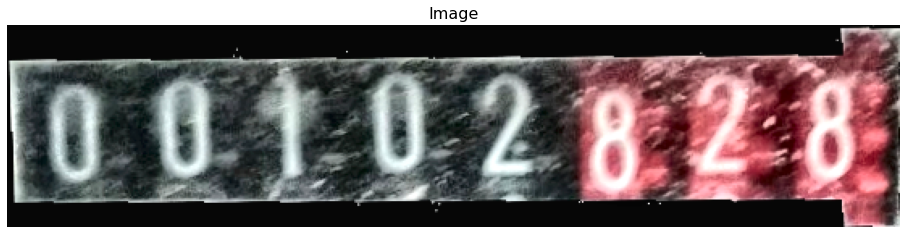

In [ ]:
img = "data/train/id_1070_value_102_828.png"
img = cv2.imread(img)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# img2 = "data/train/id_1070-2_value_102_828.png"
# img2 = cv2.imread(img2)
# img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

visualize(
    image=img,
    # image2=img2,
)

In [ ]:
!tree data/valid/

In [ ]:
for x, y in zip(X_cut_train[844:865], y_train[844:865]):
    print(x,'\t\t', y)

./data/train/id_1227_value_53_156.png 		 00053.156
./data/train/id_559_value_281_821.png 		 00281.821
./data/train/id_447_value_749_431.png 		 00749.431
./data/train/id_1144-2_value_590_053.png 		 00590.053
./data/train/id_1221-2_value_15_418.png 		 00015.418
./data/train/id_467-2_value_127_201.png 		 00127.201
./data/train/id_920-2_value_112_725.png 		 00112.725
./data/train/id_333-2_value_849_037.png 		 00849.037
./data/train/id_843-2_value_198_639.png 		 00198.639
./data/train/id_233-2_value_370_276.png 		 00370.276
./data/train/id_1070-2_value_102_828.png 		 00102.828
./data/train/id_600-2_value_358_581.png 		 00358.581
./data/train/id_640-2_value_359_439.png 		 00359.439
./data/train/id_816-2_value_545_577.png 		 00545.577
./data/train/id_905-2_value_19_368.png 		 00019.368
./data/train/id_705-2_value_425_98.png 		 00425.980
./data/train/id_1242-2_value_209_385.png 		 00209.385
./data/train/id_1-2_value_13_116.png 		 00013.116
./data/train/id_710-2_value_108_928.png 		 00108.928
.

In [ ]:
for x, y in zip(X_cut_train, y_train):
    print(x,'\t\t', y)

In [ ]:
# !rm -r ./data/train/
# !rm -r ./data/valid/

# MODEL CRNN
- Convolutional + Recurrent Neural Nets

In [ ]:
# !pip install numba
# from numba import cuda

# cuda.select_device(0)
# cuda.close()

In [ ]:
tf.keras.backend.clear_session()

def feature_extractor(input_tensor): 
    ACTIV="swish"
    # ACTIV='relu'
    paddi= 'same'
    x = tf.keras.layers.Conv2D(
        64,  (3, 3), padding=paddi, activation=ACTIV, name='conv1', kernel_initializer='he_normal')(input_tensor)
    #     64,  (3, 3), padding=paddi, use_bias=False, activation=None, name='conv1', kernel_initializer='he_normal')(input_tensor)
    # x = tf.keras.layers.BatchNormalization(name='bn1')(x)
    # x = tf.keras.layers.Activation(ACTIV, name='Acti1')(x)
        
    x = tf.keras.layers.MaxPool2D(pool_size=2, strides=2,  padding='valid', name='pool1')(x)

    x = tf.keras.layers.Conv2D(
        128, 3, padding=paddi, use_bias=False, activation=None, name='conv2', kernel_initializer='he_normal')(x)
    x = tf.keras.layers.BatchNormalization(name='bn2')(x)
    x = tf.keras.layers.Activation(ACTIV, name='Acti2')(x)
    
    x = tf.keras.layers.MaxPool2D(pool_size=2, strides=2, padding='valid', name='pool2')(x)

    # x = tf.keras.layers.Conv2D(256, 3, padding=paddi, use_bias=True, activation=ACTIV, kernel_initializer='he_normal', name='conv3')(x)
    x = tf.keras.layers.Conv2D(256, 3, padding=paddi, use_bias=False, activation=None, kernel_initializer='he_normal', name='conv3')(x)
    x = tf.keras.layers.BatchNormalization(name='bn3')(x)
    x = tf.keras.layers.Activation(ACTIV, name='Acti3')(x)
    # x = tf.keras.layers.Conv2D(256, 3, padding=paddi, use_bias=True, activation=ACTIV, kernel_initializer='he_normal', name='conv4')(x)
    x = tf.keras.layers.Conv2D(256, 3, padding=paddi, use_bias=False, activation=None, kernel_initializer='he_normal', name='conv4')(x)
    x = tf.keras.layers.BatchNormalization(name='bn4')(x)
    x = tf.keras.layers.Activation(ACTIV, name='Acti4')(x)
    x = tf.keras.layers.MaxPool2D(
        pool_size=(2,2), strides=(2, 1), padding='same', name='pool3')(x)

    x = tf.keras.layers.Conv2D(512, 3, padding=paddi, use_bias=False, kernel_initializer='he_normal', name='conv5')(x)
    x = tf.keras.layers.BatchNormalization(name='bn5')(x)
    x = tf.keras.layers.Activation(ACTIV, name='Acti5')(x)

    x = tf.keras.layers.Conv2D(512, 3, padding=paddi, use_bias=False, kernel_initializer='he_normal', name='conv6')(x)
    # x = tf.keras.layers.Conv2D(512, 3, strides=2, padding=paddi, use_bias=False, kernel_initializer='he_normal', name='conv6')(x)
    x = tf.keras.layers.BatchNormalization(name='bn6')(x)
    x = tf.keras.layers.Activation(ACTIV, name='Acti6')(x)

    x = tf.keras.layers.MaxPool2D(
        # pool_size=(2, 2), strides=(2, 1), padding='same', name='pool4' )(x)
        pool_size=(2, 2), strides=(2, 2), padding='same', name='pool4' )(x)

    # x = tf.keras.layers.Conv2D(512, 3, strides=2, padding=paddi, use_bias=False, kernel_initializer='he_normal', name='conv6-bis')(x)
    # x = tf.keras.layers.BatchNormalization(name='bn6-bis')(x) ## this layer makes the training faster
    # x = tf.keras.layers.Activation(ACTIV, name='Acti6-bis')(x)

    # x = tf.keras.layers.Conv2D(512, 2, strides=(3, 1), padding='same', use_bias=True, activation=ACTIV, kernel_initializer='he_normal', name='conv7')(x)
    # x = tf.keras.layers.Conv2D(512, 2, strides=(3, 2), padding='same', use_bias=True, activation=ACTIV, kernel_initializer='he_normal', name='conv7')(x)
    # x = tf.keras.layers.Conv2D(512, 3, padding='same', use_bias=True, activation=ACTIV, kernel_initializer='he_normal', name='conv7')(x)
    x = tf.keras.layers.Conv2D(512, 3, padding='same', use_bias=False, activation=None, kernel_initializer='he_normal', name='conv7')(x)
    x = tf.keras.layers.BatchNormalization(name='bn7')(x)
    x = tf.keras.layers.Activation(ACTIV, name='Acti7')(x)
    
    # # Max-pooling layers are worse at preserving localization --> AveragePooling fits here better
    # x = tf.keras.layers.AveragePooling2D((2, 2), strides = (3, 1), name='avg_pool1', padding ='same')(x)
    x = tf.keras.layers.AveragePooling2D((2, 2), strides = (2, 1), name='avg_pool1', padding ='valid')(x)
    # x = tf.keras.layers.AveragePooling2D((2, 2), strides = (2, 2), name='avg_pool1', padding ='same')(x)

    x = tf.keras.layers.Reshape((-1, 512), name='reshape7')(x)
    return x

def build_model(num_classes, shape ):
    """build CNN-RNN model"""

    img_input = tf.keras.Input(shape=shape)
    x = feature_extractor(img_input)
    # x = tf.keras.layers.LSTM(units=256, return_sequences=True, name='LSTM1')(x) # lstm achieves 0.5%
    # xx = tf.keras.layers.LSTM(units=128, return_sequences=True, kernel_initializer='he_uniform', name='LSTM1')(x) # lstm achieves 0.5%
    xx = tf.keras.layers.LSTM(units=64, return_sequences=True, kernel_initializer='he_uniform', name='LSTM1' , dropout=0.4)
    x = tf.keras.layers.Bidirectional(xx, merge_mode='mul') (x)
    # x = tf.keras.layers.Bidirectional(xx ) (x)
    # x = tf.keras.layers.Dropout(.2)(x)
    # x = tf.keras.layers.LSTM(units=32, return_sequences=True,  name='LSTM2')(x) # lstm achieves 0.5%
    x = tf.keras.layers.Dense(units=num_classes, name='Fc1', kernel_initializer='he_uniform' )(x)

    return tf.keras.Model(inputs=img_input, outputs=x, name='CRNN')


model = build_model(num_classes=data_builder.num_classes, shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)) 
# model = build_model(num_classes=data_builder.num_classes, img_height=40, img_width=160, img_channels=IMG_CHANNELS) 
model.summary()

Model: "CRNN"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         [(None, 40, 160, 3)]      0         
_________________________________________________________________
conv1 (Conv2D)               (None, 40, 160, 64)       1792      
_________________________________________________________________
pool1 (MaxPooling2D)         (None, 20, 80, 64)        0         
_________________________________________________________________
conv2 (Conv2D)               (None, 20, 80, 128)       73728     
_________________________________________________________________
bn2 (BatchNormalization)     (None, 20, 80, 128)       512       
_________________________________________________________________
Acti2 (Activation)           (None, 20, 80, 128)       0         
_________________________________________________________________
pool2 (MaxPooling2D)         (None, 10, 40, 128)       0      

In [ ]:
tf.keras.backend.clear_session()

def feature_extractor(input_tensor): # TODO: modify the kernel_initializer='he_normal'
    ACTIV="swish"
    # ACTIV='relu'
    paddi= 'same'
    x = tf.keras.layers.Conv2D(
        64,  (3, 3), padding=paddi, activation=ACTIV, name='conv1')(input_tensor)
    x = tf.keras.layers.MaxPool2D(pool_size=2, strides=2,  padding='valid', name='pool1')(x)

    x = tf.keras.layers.Conv2D(
        128, 3, padding=paddi, activation=ACTIV, name='conv2')(x)
    
    x = tf.keras.layers.MaxPool2D(pool_size=2, strides=2, padding='valid', name='pool2')(x)

    x = tf.keras.layers.Conv2D(256, 3, padding=paddi, use_bias=True, activation=ACTIV, name='conv3')(x)
    x = tf.keras.layers.Conv2D(256, 3, padding=paddi, use_bias=True, activation=ACTIV, name='conv4')(x)
    x = tf.keras.layers.MaxPool2D(
        pool_size=(2,2), strides=(2, 1), padding='same', name='pool3')(x)

    x = tf.keras.layers.Conv2D(512, 3, padding=paddi, use_bias=False, name='conv5')(x)
    x = tf.keras.layers.BatchNormalization(name='bn5')(x)
    x = tf.keras.layers.Activation(ACTIV, name='Relu5')(x)

    x = tf.keras.layers.Conv2D(512, 3, padding=paddi, use_bias=False, name='conv6')(x)
    x = tf.keras.layers.BatchNormalization(name='bn6')(x)
    x = tf.keras.layers.Activation(ACTIV, name='Relu6')(x)

    x = tf.keras.layers.MaxPool2D(
        pool_size=(2, 2), strides=(2, 1), padding='same', name='pool4' )(x)

    x = tf.keras.layers.Conv2D(512, 2, strides=(3, 1), padding='same', use_bias=True, activation=ACTIV, name='conv7')(x)

    x = tf.keras.layers.Reshape((-1, 512), name='reshape7')(x)
    return x

def build_model(num_classes, shape):# img_width=None, img_channels=1, img_height=32):
    """build CNN-RNN model"""

    img_input = tf.keras.Input(shape=shape)
    x = feature_extractor(img_input)
    x = tf.keras.layers.LSTM(units=256, return_sequences=True, name='LSTM1')(x) # lstm achieves 0.5%
    x = tf.keras.layers.Dense(units=num_classes, name='Fc1')(x)
    return tf.keras.Model(inputs=img_input, outputs=x, name='CRNN')



# Hyper-parameters

In [ ]:
BATCH_SIZE = 16 #12 # 32 # best 16
EPOCHS = 80 
CLIP_NORM = 1.0 # or 1.0 # or 5.0
IMG_CHANNELS = 3 # 3 # 1 to GRAY OR 3 to RGB
# IMG_HEIGHT = 64 # 40  paper mentions 160x40
# IMG_WIDTH = 288 # 160
IMG_HEIGHT = 40 #  paper mentions 40x160
IMG_WIDTH = 160
CLIP_VALUE = 5.0

In [ ]:
# # all the tested layers
# def build_model(num_classes, img_width=None, img_channels=1, img_height=32):
#     """build CNN-RNN model"""
#     # https://stackoverflow.com/questions/48714407/rnn-regularization-which-component-to-regularize
#     # ways to regularize RNN layers
#     img_input = tf.keras.Input(shape=(img_height, img_width, img_channels))
#     x = feature_extractor(img_input)
#     # --------------- attention layer try -------------
#     # 1st RNN layer
#     x = tf.keras.layers.LSTM(units=256, return_sequences=True, name='LSTM_only')(x) # lstm achieves 0.5%
#     # x = tf.keras.layers.Bidirectional(
#     # # x, state_forw, state_back = tf.keras.layers.Bidirectional(
#     #         tf.keras.layers.GRU(units=256, return_sequences=True #, return_state=True
#     #                         , kernel_regularizer=l2(1e-4) ), merge_mode='concat', name='bi_lstm1') (x)
#     # state = tf.concat([state_forw, state_back], 1)
#     # context_vector, _ = attention(x, state)
#     # x = tf.concat([tf.expand_dims(context_vector, 1), x], axis=1) # axis=-1; last axis but not working
#     # print(x.shape, state.shape, context_vector.shape, tf.expand_dims(context_vector, 1).shape)
#     # -----------------end attention-------------------
#     # 2nd RNN layer
#     # x = tf.keras.layers.Bidirectional(
#         # tf.keras.layers.LSTM(units=256, return_sequences=True)
#         #                      , merge_mode="sum", name='bi_lstm2')(x)
#     x = tf.keras.layers.Dense(units=num_classes, name='fc1')(x)
#     return tf.keras.Model(inputs=img_input, outputs=x, name='CRNN')

# # model = build_model(num_classes=data_builder.num_classes, img_height=IMG_HEIGHT, img_channels=IMG_CHANNELS
# #                     , img_width=IMG_WIDTH) # 96 is a testing for me...; 3=RGB
# # model.summary()

# Training process

### Watermeter dataset (russian)

In [ ]:
class DatasetBuilder(): # for images of the RUSSIAN dataset

    def __init__(self, table_path, img_channels, max_img_width=320, # 300 
                 img_width=None, img_height=32):
        self.table = tf.lookup.StaticHashTable(tf.lookup.TextFileInitializer(
            table_path, tf.string, tf.lookup.TextFileIndex.WHOLE_LINE, 
            tf.int64, tf.lookup.TextFileIndex.LINE_NUMBER,), default_value=-1)
        self.img_height = img_height
        self.img_channels = img_channels
        if img_width is None:
            self.max_img_width = max_img_width
            self.preserve_aspect_ratio = True
        else:
            self.img_width = img_width
            self.preserve_aspect_ratio = False
    @property
    def num_classes(self):
        return self.table.size()

    # def _decode_img(self, img, label):
    def _decode_img(self, filename, label):
        img = tf.io.read_file(filename)
        img = tf.io.decode_png(img, channels=self.img_channels)
        if self.preserve_aspect_ratio:
            img_shape = tf.shape(img)
            scale_factor = self.img_height / img_shape[0]
            img_width = scale_factor * tf.cast(img_shape[1], tf.float64)
            img_width = tf.cast(img_width, tf.int32)
        else:
            img_width = self.img_width
        
        # img = tf.image.resize(img, (self.img_height, img_width)) / 255.0
        img = tf.image.resize(img, (self.img_height, img_width)) 
        # by dividing to 255.0 is a way to normalize between 0-1      
        img = tf.keras.applications.imagenet_utils.preprocess_input(img, mode="caffe")
        return img, label

    def _filter_img(self, img, label):
        """ Keep images that have width < max_img_width. """
        img_shape = tf.shape(img)
        return img_shape[1] <= self.max_img_width

    def _tokenize(self, imgs, labels):
        chars = tf.strings.unicode_split(labels, 'UTF-8')
        tokens = tf.ragged.map_flat_values(self.table.lookup, chars)
        tokens = tokens.to_sparse()
        return imgs, tokens
        
    def build(self, img_paths, labels, batch_size, is_training):
        """
        build dataset, it will auto detect each annotation file's format.
        """
        ds = tf.data.Dataset.from_tensor_slices((img_paths, labels))

        if is_training:
            ds = ds.shuffle(buffer_size=10000)
        ds = ds.map(self._decode_img,  # reshape images inside data_builder
                    num_parallel_calls=tf.data.experimental.AUTOTUNE)
        # Ignore the errors e.g. decode error or invalid data.
        # ds = ds.apply(tf.data.experimental.ignore_errors())
        if self.preserve_aspect_ratio and batch_size != 1:
            ds = ds.filter(self._filter_img)
            ds = ds.padded_batch(batch_size, drop_remainder=is_training)
        else:
            ds = ds.batch(batch_size, drop_remainder=is_training)
        ds = ds.map(self._tokenize, 
                    num_parallel_calls=tf.data.experimental.AUTOTUNE)
        ds = ds.prefetch(tf.data.experimental.AUTOTUNE)
        return ds

In [ ]:
# X_cut_train = create_crop_save_images(X_train, "train", kernel_sz=None, apply_augmentation=get_training_augmentation())
# X_cut_valid = create_crop_save_images(X_valid, "valid", kernel_sz=None)

In [ ]:
# # X_valid[6], y_valid[6]
# # [grab_value_from_name(x) for x in X_valid][6], y_valid[6]

X_cut_valid = [os.path.join("./data/valid", x.rsplit('.', 1)[0]+".png") for x in X_valid]
X_cut_train = [os.path.join("./data/train", x.rsplit('.', 1)[0]+".png") for x in X_train]
uniques = []
counter =0
for i in range(len(X_cut_train)):
    if X_cut_train[i] in uniques:
        X_cut_train[i] = X_cut_train[i].replace("_v", "-2_v")
        counter +=1
    uniques.append(X_cut_train[i])
len(X_cut_train), len(X_cut_valid)

(847, 363)

In [ ]:
# # counter
# import collections
# dups = [item for item, count in collections.Counter(X_cut_train).items() if count > 1]
# print(len(dups))

In [ ]:
# for x, y in zip(X_cut_train, y_train):
#     print(x,'\t\t', y)
for x, y in zip(X_cut_train[844:865], y_train[844:865]):
    print(x,'\t\t', y)

In [ ]:
X_cut_valid[55], X_valid[55], y_valid[55]
# X_cut_train[6], X_train[6], y_train[6]

('./data/valid/id_413_value_561_627.png',
 'id_413_value_561_627.jpg',
 '00561.627')

In [ ]:
data_builder = DatasetBuilder(TABLE_path, img_channels=IMG_CHANNELS, img_height=IMG_HEIGHT
                              , img_width=IMG_WIDTH
                              )
# data_builder.num_classes
train_loader = data_builder.build(X_cut_train, y_train, BATCH_SIZE, is_training=True)
val_loader = data_builder.build(X_cut_valid, y_valid, BATCH_SIZE, False)

In [ ]:
for (batch, (inp, tar)) in enumerate(val_loader):
# for (batch, (inp, tar)) in enumerate(train_loader):
    print(batch, inp.shape, tar.shape)
    break


0 (16, 40, 160, 3) (16, 9)


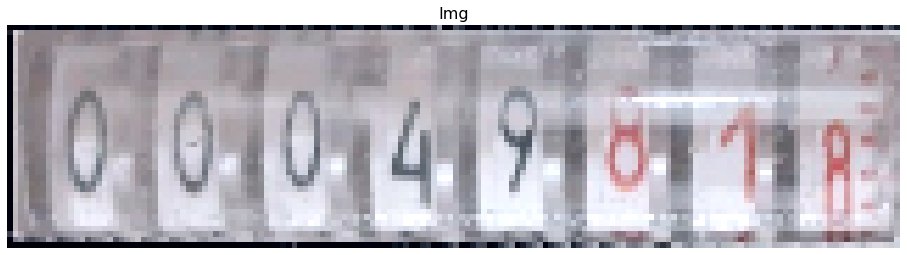

image: 0 <dtype: 'float32'> (40, 160, 3) 150.4285 -123.68
tf.Tensor([ 0  0  0  4  9 10  8  1  8], shape=(9,), dtype=int64)


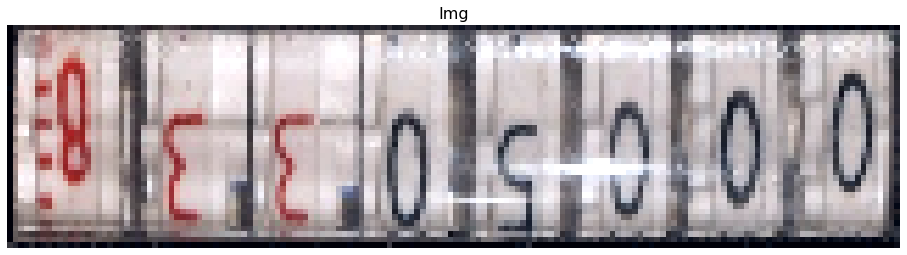

image: 1 <dtype: 'float32'> (40, 160, 3) 151.061 -123.68
tf.Tensor([ 0  0  0  5  0 10  3  3  8], shape=(9,), dtype=int64)


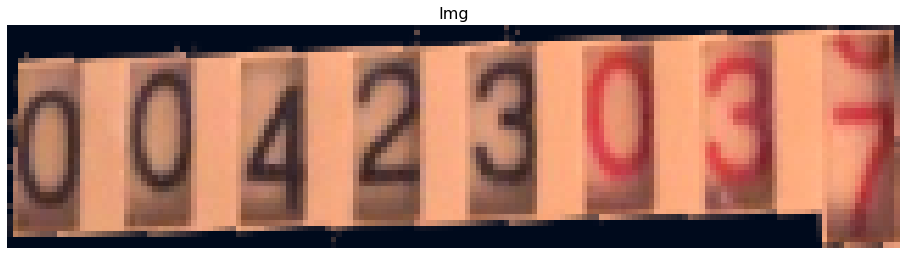

image: 2 <dtype: 'float32'> (40, 160, 3) 68.429344 -123.68
tf.Tensor([ 0  0  4  2  3 10  0  3  7], shape=(9,), dtype=int64)


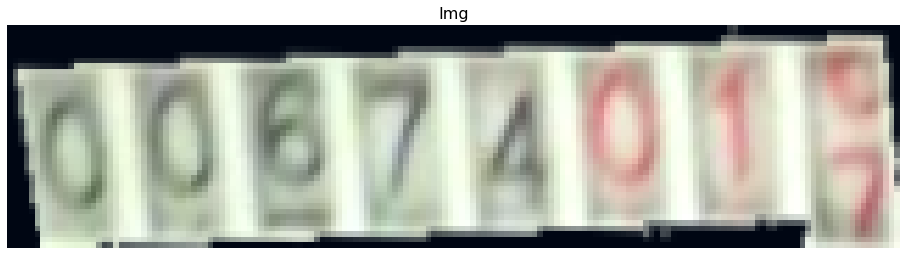

image: 3 <dtype: 'float32'> (40, 160, 3) 138.16943 -123.68
tf.Tensor([ 0  0  6  7  4 10  0  1  7], shape=(9,), dtype=int64)


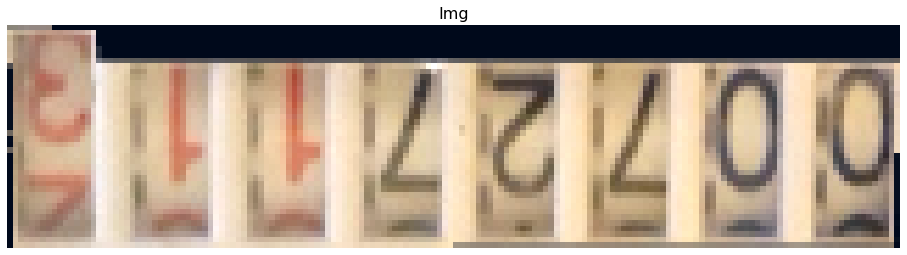

image: 4 <dtype: 'float32'> (40, 160, 3) 76.77305 -123.68
tf.Tensor([ 0  0  7  2  7 10  1  1  3], shape=(9,), dtype=int64)


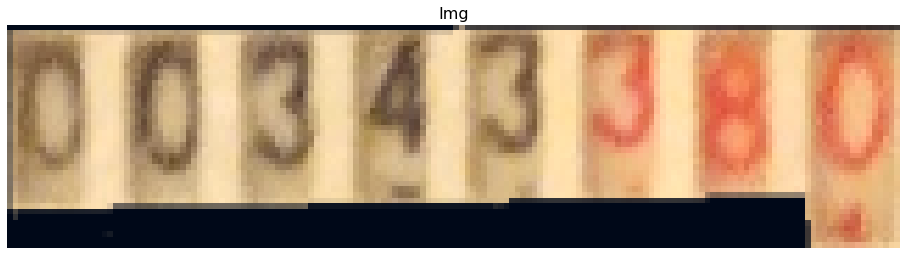

image: 5 <dtype: 'float32'> (40, 160, 3) 88.86558 -123.68
tf.Tensor([ 0  0  3  4  3 10  3  8  0], shape=(9,), dtype=int64)


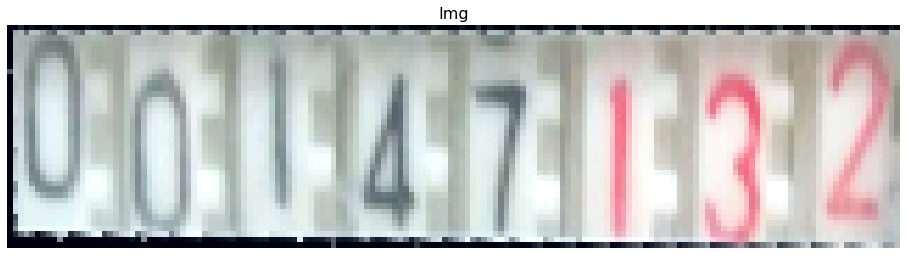

image: 6 <dtype: 'float32'> (40, 160, 3) 86.344444 -123.68
tf.Tensor([ 0  0  1  4  7 10  1  3  2], shape=(9,), dtype=int64)


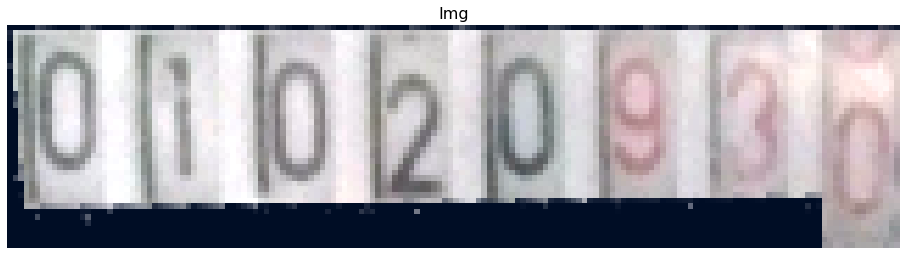

image: 7 <dtype: 'float32'> (40, 160, 3) 22.804573 -123.68
tf.Tensor([ 0  1  0  2  0 10  9  3  0], shape=(9,), dtype=int64)


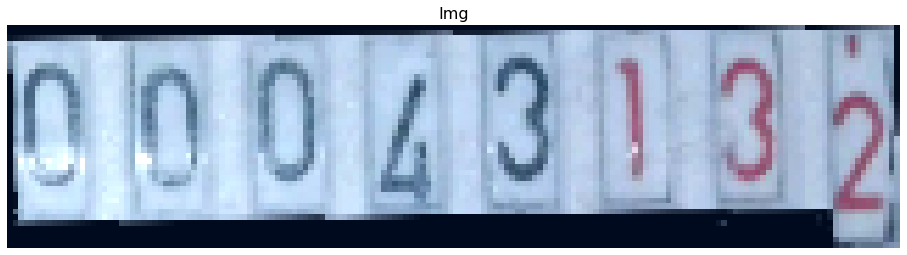

image: 8 <dtype: 'float32'> (40, 160, 3) 126.65087 -123.68
tf.Tensor([ 0  0  0  4  3 10  1  3  2], shape=(9,), dtype=int64)


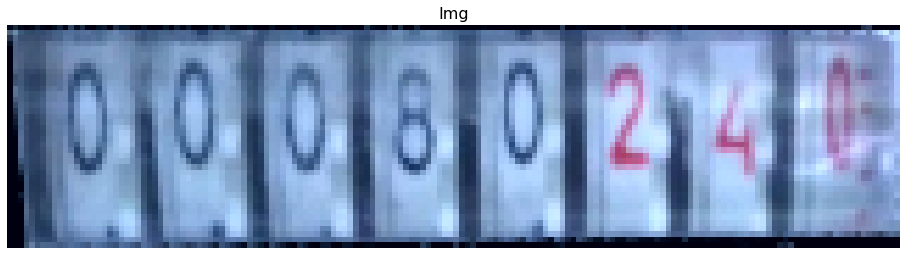

image: 9 <dtype: 'float32'> (40, 160, 3) 105.19694 -123.68
tf.Tensor([ 0  0  0  8  0 10  2  4  0], shape=(9,), dtype=int64)


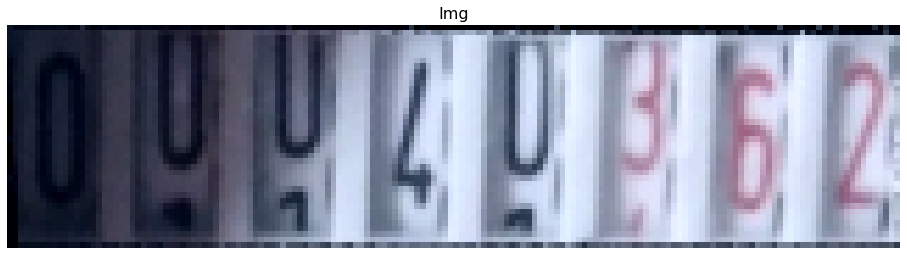

image: 10 <dtype: 'float32'> (40, 160, 3) 120.061 -123.68
tf.Tensor([ 0  0  0  4  0 10  3  6  2], shape=(9,), dtype=int64)


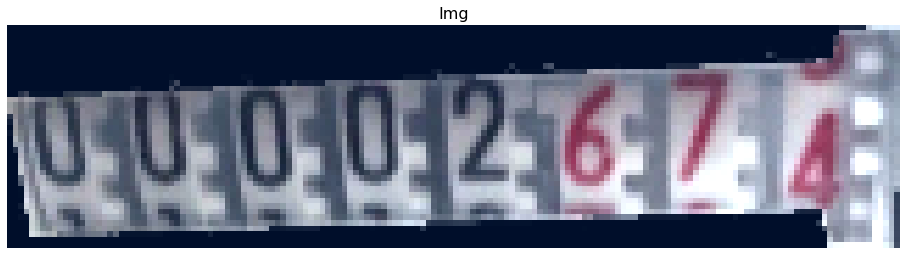

image: 11 <dtype: 'float32'> (40, 160, 3) 50.242683 -123.68
tf.Tensor([ 0  0  0  0  2 10  6  7  4], shape=(9,), dtype=int64)


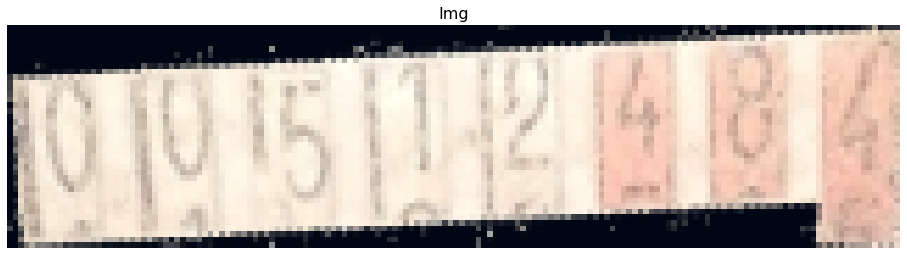

image: 12 <dtype: 'float32'> (40, 160, 3) 133.44858 -123.68
tf.Tensor([ 0  0  5  1  2 10  4  8  4], shape=(9,), dtype=int64)


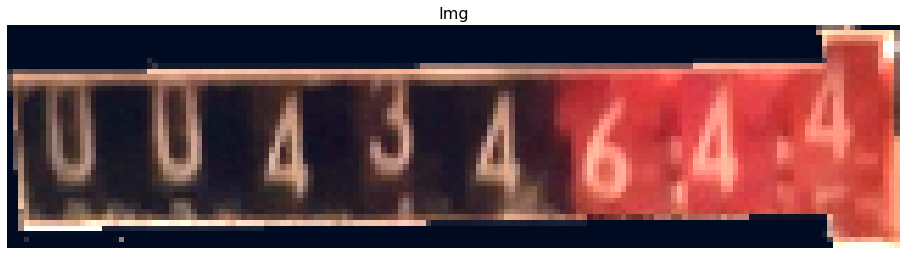

image: 13 <dtype: 'float32'> (40, 160, 3) 127.270836 -123.68
tf.Tensor([ 0  0  4  3  4 10  6  4  4], shape=(9,), dtype=int64)


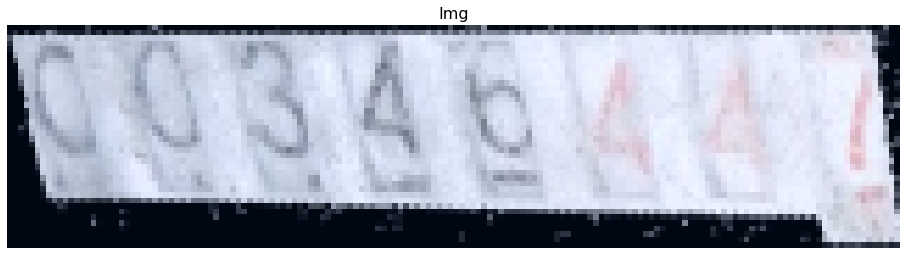

image: 14 <dtype: 'float32'> (40, 160, 3) 151.061 -123.68
tf.Tensor([ 0  0  3  4  6 10  4  4  7], shape=(9,), dtype=int64)


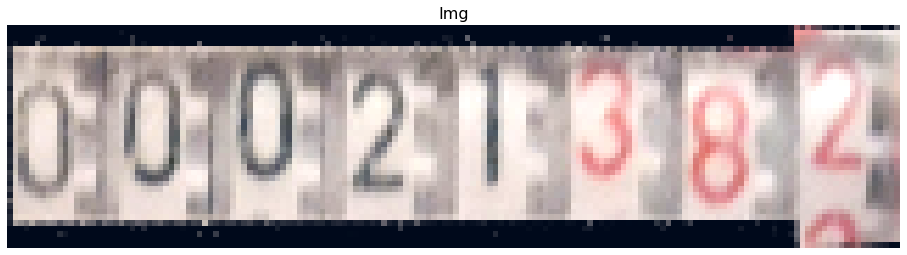

image: 15 <dtype: 'float32'> (40, 160, 3) 80.83874 -123.68
tf.Tensor([ 0  0  0  2  1 10  3  8  2], shape=(9,), dtype=int64)


In [ ]:
for i in range(len(inp)):
    visualize(        
        # img = inp[i][..., 0]
        # img = inp[i]
        img = denormalize( inp[i].numpy() )
        # , colormap="gray"
    )
    print("image:", i ,inp[i].dtype, inp[i].shape, np.max(inp[i]), np.min(inp[i]))
    print(tf.sparse.to_dense(tar) [i])

## Build model

In [ ]:
# optimizer = tf.keras.optimizers.Adam(0.0005, clipnorm=CLIP_NORM) # SO FAR THE BEST
# optimizer = tf.keras.optimizers.Adam(0.00058, clipnorm=CLIP_NORM) 

# optimizer = tf.keras.optimizers.Adam(0.0002, clipnorm=CLIP_NORM) # 
# optimizer = tf.keras.optimizers.Adam(0.0002) # SO FAR working
# optimizer = tf.keras.optimizers.SGD(learning_rate=0.0002, momentum=0.9, clipnorm=CLIP_NORM)
optimizer = tf.keras.optimizers.RMSprop(0.001, clipnorm=CLIP_NORM)
# optimizer = tf.keras.optimizers.RMSprop(0.0002, clipvalue=CLIP_VALUE)

optimizer.learning_rate

<tf.Variable 'learning_rate:0' shape=() dtype=float32, numpy=0.001>

In [ ]:
model = build_model(num_classes=data_builder.num_classes, shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)) 

## Loss-object

In [ ]:
class CTCLoss(tf.keras.losses.Loss):
    def __init__(self, logits_time_major=False, blank_index=-1, 
                 reduction=tf.keras.losses.Reduction.AUTO, name='ctc_loss'):
        super().__init__(reduction=reduction, name=name)
        self.logits_time_major = logits_time_major
        self.blank_index = blank_index

    def call(self, y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        logit_length = tf.fill([tf.shape(y_pred)[0]], tf.shape(y_pred)[1])
        loss = tf.nn.ctc_loss(
            labels=y_true,
            logits=y_pred,
            label_length=None,
            logit_length=logit_length,
            logits_time_major=self.logits_time_major,
            blank_index=self.blank_index)
        return tf.reduce_mean(loss)


## Accuracy object

In [ ]:
class SequenceAccuracy(tf.keras.metrics.Metric):
    """ Calculate the word accuracy between y_true and y_pred. """
    def __init__(self, name='seq_accuracy', **kwargs):
        super().__init__(name=name, **kwargs)
        self.total = self.add_weight(name='total', initializer='zeros')
        self.count = self.add_weight(name='count', initializer='zeros')
                
    def update_state(self, y_true, y_pred, sample_weight=None):
        batch_size = tf.shape(y_true)[0]
        max_width = tf.maximum(tf.shape(y_true)[1], tf.shape(y_pred)[1])
        logit_length = tf.fill([tf.shape(y_pred)[0]], tf.shape(y_pred)[1])        
        decoded, _ = tf.nn.ctc_greedy_decoder(
            inputs=tf.transpose(y_pred, perm=[1, 0, 2]),
            sequence_length=logit_length)
        y_true = self.to_dense(y_true, [batch_size, max_width])
        y_pred = self.to_dense(decoded[0], [batch_size, max_width])
        num_errors = tf.math.reduce_any(
            tf.math.not_equal(y_true, y_pred), axis=1)
        num_errors = tf.cast(num_errors, tf.float32)
        num_errors = tf.reduce_sum(num_errors)
        batch_size = tf.cast(batch_size, tf.float32)
        self.total.assign_add(batch_size)
        self.count.assign_add(batch_size - num_errors)

    def to_dense(self, tensor, shape):
        tensor = tf.sparse.reset_shape(tensor, shape)
        tensor = tf.sparse.to_dense(tensor, default_value=-1)
        tensor = tf.cast(tensor, tf.float32)
        return tensor

    def result(self):
        return self.count / self.total

    def reset_states(self):
        self.count.assign(0)
        self.total.assign(0)

class EditDistance(tf.keras.metrics.Metric):
    '''Computes the Levenshtein distance between sequences.'''
    def __init__(self, name='edit_dist', **kwargs):
        super().__init__(name=name, **kwargs)
        self.total = self.add_weight(name='total', initializer='zeros')
        self.sum_distance = self.add_weight(name='sum_distance', 
                                            initializer='zeros')
                
    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred_shape = tf.shape(y_pred)
        batch_size = y_pred_shape[0]
        logit_length = tf.fill([batch_size], y_pred_shape[1])      
        decoded, _ = tf.nn.ctc_greedy_decoder(
            inputs=tf.transpose(y_pred, perm=[1, 0, 2]),
            sequence_length=logit_length)
        sum_distance = tf.math.reduce_sum(tf.edit_distance(decoded[0], y_true))
        batch_size = tf.cast(batch_size, tf.float32)
        self.sum_distance.assign_add(sum_distance)
        self.total.assign_add(batch_size)

    def result(self):
        return self.sum_distance / self.total

    def reset_states(self):
        self.sum_distance.assign(0)
        self.total.assign(0)
 

## Callbacks

In [ ]:
# delete previous session
!rm -r logs_CRNN/
!rm -r CRNN_model/ 

# class DecayHistory(tf.keras.callbacks.Callback):
#     def on_train_begin(self, logs={}):
#         self.lr = []
#         self.wd = []
#     def on_batch_end(self, batch, logs={}):
#         self.lr.append(self.model.optimizer.lr(self.model.optimizer.iterations))
#         self.wd.append(self.model.optimizer.weight_decay)

dir_name = "./{}_{}".format(model.name, 'model')
print(f"Model checkpoints dir: {dir_name}")
!mkdir $dir_name

callbacks = [

    tf.keras.callbacks.ModelCheckpoint(
                '{}/{}_{}_best_model.h5'.format(dir_name, model.name,
                                        'model')
                    , save_weights_only=True, save_best_only=True, mode='max'
                    , monitor='val_seq_accuracy'),
    tf.keras.callbacks.ModelCheckpoint(
                '{}/{}_{}_loss_model.h5'.format(dir_name, model.name,'model')
                    , save_weights_only=True, save_best_only=True, mode='min'
                    , monitor='val_loss'),
             
    # tf.keras.callbacks.ReduceLROnPlateau(monitor='val_word_accuracy', mode='max',
    #                                   factor=0.5, patience=15, min_lr=0.0001, verbose=1)
    # XTensorBoard(log_dir=str(args.model_dir), **config['tensorboard'])
    tf.keras.callbacks.TensorBoard(log_dir='logs_CRNN', profile_batch = 0 #'10, 25'
                                    )
    # , DecayHistory()
    ]

model.compile(optimizer=optimizer,
                  loss=CTCLoss(), metrics=[SequenceAccuracy(), EditDistance()])

Model checkpoints dir: ./CRNN_model


## Training steps

In [ ]:
start_train = time.time() 

history = model.fit(train_loader, epochs=EPOCHS, callbacks=callbacks,
                        validation_data=val_loader
                    )

print('[TRAINING FINISHED]\n'
                'Model trained during {} \n'.format( asHHMMSS( time.time() - start_train)))

Epoch 1/80
52/52 [==============================] - 8s 79ms/step - loss: 23.6231 - seq_accuracy: 0.0000e+00 - edit_dist: 0.9649 - val_loss: 22.7945 - val_seq_accuracy: 0.0000e+00 - val_edit_dist: 0.9174
Epoch 2/80
52/52 [==============================] - 3s 58ms/step - loss: 18.6543 - seq_accuracy: 0.0000e+00 - edit_dist: 0.8607 - val_loss: 18.3356 - val_seq_accuracy: 0.0000e+00 - val_edit_dist: 0.8206
Epoch 3/80
52/52 [==============================] - 3s 59ms/step - loss: 17.2250 - seq_accuracy: 0.0000e+00 - edit_dist: 0.7210 - val_loss: 16.7747 - val_seq_accuracy: 0.0000e+00 - val_edit_dist: 0.6967
Epoch 4/80
52/52 [==============================] - 3s 59ms/step - loss: 16.1650 - seq_accuracy: 0.0000e+00 - edit_dist: 0.6500 - val_loss: 16.4193 - val_seq_accuracy: 0.0000e+00 - val_edit_dist: 0.6667
Epoch 5/80
52/52 [==============================] - 3s 59ms/step - loss: 15.8365 - seq_accuracy: 0.0000e+00 - edit_dist: 0.6360 - val_loss: 16.3064 - val_seq_accuracy: 0.0000e+00 - val_edi

In [ ]:
model.load_weights('{}/{}_{}_best_model.h5'.format(dir_name, model.name,
                                        'model'))   # 1s 34ms/step - loss: 3.8611 - seq_accuracy: 0.6612 - edit_distance: 0.0744
                                                    # 1s 23ms/step - loss: 3.4816 - seq_accuracy: 0.6198 - edit_distance: 0.0774
                                                    # 1s 26ms/step - loss: 4.9099 - seq_accuracy: 0.6033 - edit_distance: 0.0869
model.evaluate(val_loader)

23/23 [==============================] - 1s 24ms/step - loss: 3.9955 - seq_accuracy: 0.6722 - edit_dist: 0.0747


[3.995461940765381, 0.6721763014793396, 0.07468624413013458]

In [ ]:
model.evaluate(val_loader)

23/23 [==============================] - 1s 26ms/step - loss: 5.1033 - seq_accuracy: 0.5179 - edit_distance: 0.1068


[5.103285789489746, 0.5179063081741333, 0.1068258285522461]

In [ ]:
model.load_weights('{}/{}_{}_loss_model.h5'.format(dir_name, model.name,'model'))                                                      
model.evaluate(val_loader)

23/23 [==============================] - 1s 24ms/step - loss: 3.5655 - seq_accuracy: 0.5372 - edit_dist: 0.1001


[3.5655105113983154, 0.5371900796890259, 0.10009182244539261]

In [ ]:
model.evaluate(val_loader)

24/24 [==============================] - 1s 22ms/step - loss: 74.5152 - word_accuracy: 0.0000e+00 - edit_distance: 0.9571


[74.53752136230469, 0.0, 0.9582960605621338]

In [ ]:
model.load_weights('{}/{}_{}_best_model.h5'.format(dir_name, model.name,
                                        'model'))
model.evaluate(val_loader)

24/24 [==============================] - 1s 22ms/step - loss: 5.9868 - word_accuracy: 0.3914 - edit_distance: 0.1192


[5.9868292808532715, 0.3914209008216858, 0.11915399134159088]

### Visualization of the training

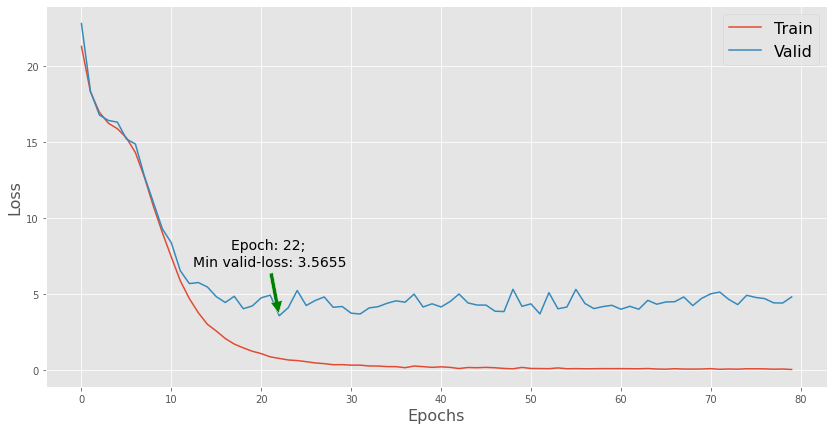

In [ ]:
plt.style.use('ggplot')

def plot_loss(hist):
    plt.figure(figsize=(14, 7))

    plt.plot(hist['loss'], label='Train')
    plt.plot(hist['val_loss'], label='Valid')

    plt.annotate(f"Epoch: { np.argmin(hist['val_loss']) }; \nMin valid-loss: {min(hist['val_loss']) :.4f}"
                , xy =( np.argmin(hist['val_loss'] ) , min( hist['val_loss'] ) ), 
                textcoords="offset points", # how to position the text
                 xytext=( -9 , 50), # distance from text to points (x,y)
                 ha='center', # horizontal alignment can be left, right or center
                arrowprops = dict(facecolor ='green', 
                                  shrink = 0.05), fontsize=14
            )
    plt.xlabel('Epochs', fontsize=16)
    plt.ylabel('Loss', fontsize=16)
    plt.legend(fontsize=16)

plot_loss(history.history)

In [ ]:
history.history

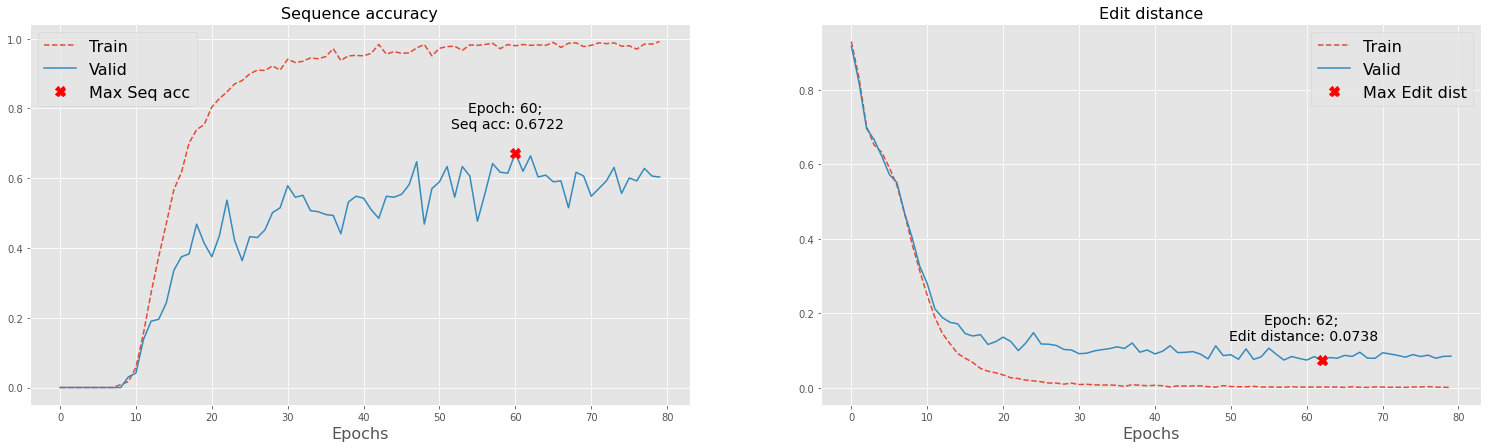

In [ ]:
def plot_evaluations(hist):
    f, (ax1, ax2) = plt.subplots(1, 2, figsize=(26, 7))

    ax1.plot(hist['seq_accuracy'],  '--', label='Train')
    ax1.plot(hist['val_seq_accuracy'],  '-', label='Valid')
    ax1.plot( np.argmax(hist['val_seq_accuracy']), max(hist['val_seq_accuracy']), linestyle="None", color="red", marker="X"
        , markersize=10, label='Max Seq acc')
    
    ax1.annotate(f"Epoch: {np.argmax(hist['val_seq_accuracy'])}; \nSeq acc: {max(hist['val_seq_accuracy']) :.4f}"
                , xy =(np.argmax(hist['val_seq_accuracy']) , max(hist['val_seq_accuracy'])), 
                textcoords="offset points", # how to position the text
                #  xytext=( 5 , 50), # distance from text to points (x,y)
                 xytext=( -8 , 25), # distance from text to points (x,y)
                 ha='center', # horizontal alignment can be left, right or center
                # arrowprops = dict(facecolor ='green', 
                #                   shrink = 0.05)
                # va='bottom',
                fontsize=14
             ) 
    ax1.set_title(label='Sequence accuracy', fontsize=16)
    ax1.set_xlabel('Epochs', fontsize=16)
    ax1.legend(fontsize=16)

    ax2.plot(hist['edit_dist'],  '--',  label='Train')
    ax2.plot(hist['val_edit_dist'],  '-', label='Valid')
    ax2.plot( np.argmin(hist['val_edit_dist']), min(hist['val_edit_dist']), linestyle="None", color="red", marker="X"
        , markersize=10, label=r'Min Edit dist')
    ax2.annotate(f"Epoch: {np.argmin(hist['val_edit_dist'])}; \nEdit distance: {min(hist['val_edit_dist']) :.4f}"
                , xy =(np.argmin(hist['val_edit_dist']) , min(hist['val_edit_dist'])), 
                textcoords="offset points", # how to position the text
                #  xytext=( 5 , 50), # distance from text to points (x,y)
                 xytext=( -18 , 20), # distance from text to points (x,y)
                 ha='center', # horizontal alignment can be left, right or center
                fontsize=14
             ) 

    ax2.set_title(label='Edit distance', fontsize=16)
    ax2.set_xlabel('Epochs', fontsize=16)
    ax2.legend(fontsize=16)

plot_evaluations(history.history)

In [ ]:
# Load the TensorBoard notebook extension.
%load_ext tensorboard
%tensorboard --logdir logs_CRNN/

In [ ]:
!kill 4062
# !rm -r logs_CRNN/

## Predictions

In [ ]:
def CTCdecoder():
    def decoder(inputs):        
        logit_length = tf.fill([tf.shape(inputs)[0]], tf.shape(inputs)[1])
        decoded, _ = tf.nn.ctc_greedy_decoder(
                    inputs=tf.transpose(inputs, perm=[1, 0, 2]),
                    sequence_length=logit_length,
                    merge_repeated=True)
        inputs = decoded[0]
        decoded = tf.sparse.to_dense(inputs, 
                                     default_value=-1)#.numpy()
        return decoded

    return tf.keras.layers.Lambda(decoder, name='decode')

class Decoder:
    def __init__(self, table, blank_index=-1, merge_repeated=True):
        """ Args:
                table: list, char map
                blank_index: int(default: num_classes - 1), the index of blank 
            label.
                merge_repeated: bool
        """
        self.table = table
        if blank_index == -1:
            blank_index = len(table) - 1
        self.blank_index = blank_index
        self.merge_repeated = merge_repeated

    def map2string(self, inputs):
        strings = []
        for i in inputs:
            text = [self.table[char_index] for char_index in i 
                    if char_index != self.blank_index]
            strings.append(''.join(text))
        return strings

    def decode(self, inputs, from_pred=True, method='greedy'):
        if from_pred:
            logit_length = tf.fill([tf.shape(inputs)[0]], tf.shape(inputs)[1])
            if method == 'greedy':
                decoded, _ = tf.nn.ctc_greedy_decoder(
                    inputs=tf.transpose(inputs, perm=[1, 0, 2]),
                    sequence_length=logit_length,
                    merge_repeated=self.merge_repeated)
            elif method == 'beam':
                decoded, _ = tf.nn.ctc_beam_search_decoder(
                    inputs=tf.transpose(inputs, perm=[1, 0, 2]),
                    # sequence_length=logit_length, beam_width=3)
                    sequence_length=logit_length)
            inputs = decoded[0]
        decoded = tf.sparse.to_dense(inputs, 
                                    #  default_value=-1).numpy() 
                                     default_value=self.blank_index).numpy()
        decoded = self.map2string(decoded)
        return decoded

In [ ]:
table

['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '.', '<BLK>']

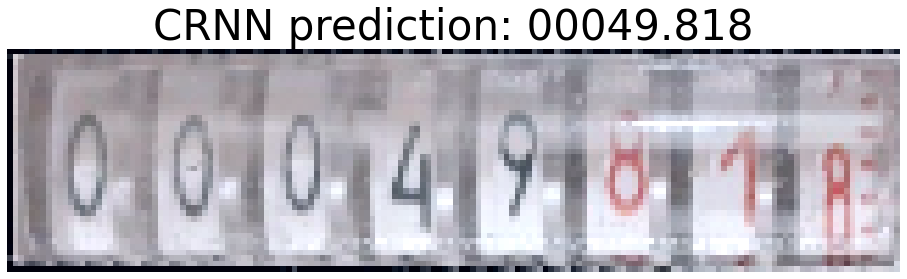

Image 1:
Greedy pred: 00049.818
Actual targ: 00049.818 


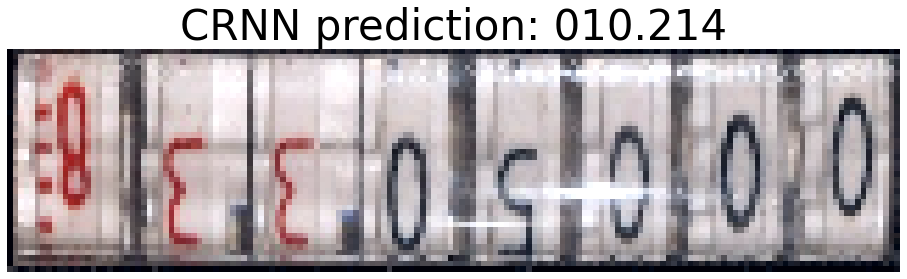

Image 2:
Greedy pred: 010.214
Actual targ: 00050.338 


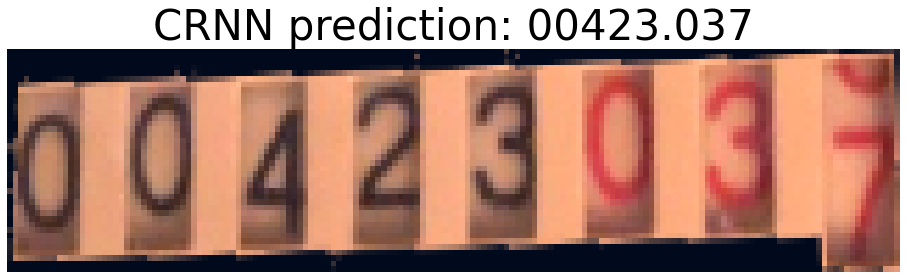

Image 3:
Greedy pred: 00423.037
Actual targ: 00423.037 


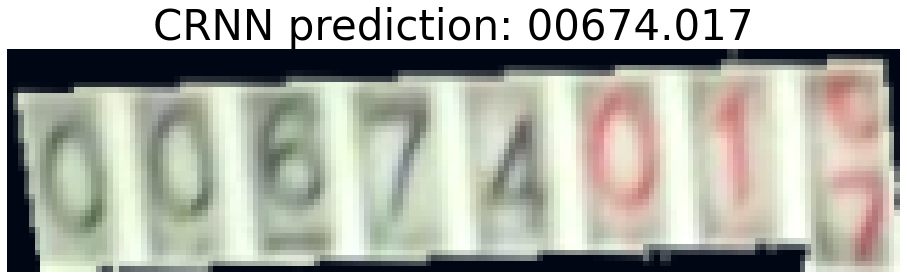

Image 4:
Greedy pred: 00674.017
Actual targ: 00674.017 


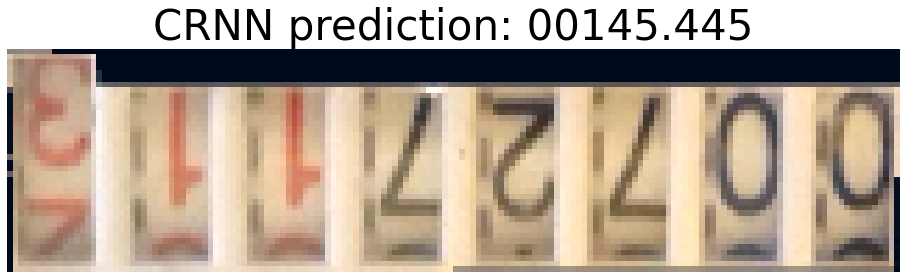

Image 5:
Greedy pred: 00145.445
Actual targ: 00727.113 


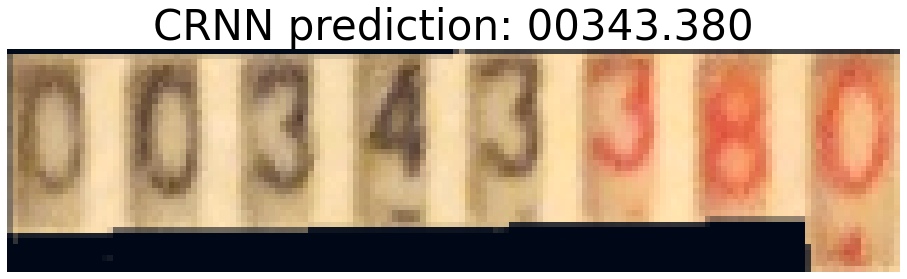

Image 6:
Greedy pred: 00343.380
Actual targ: 00343.380 


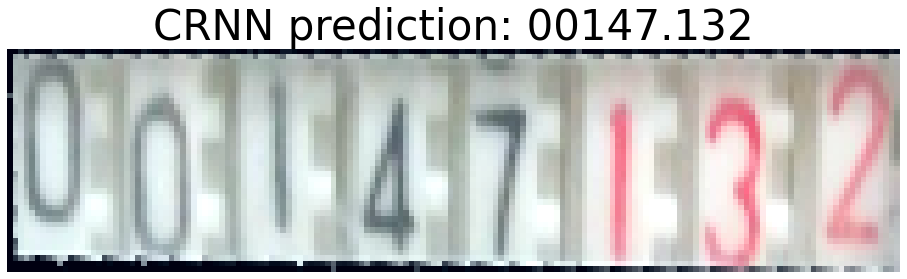

Image 7:
Greedy pred: 00147.132
Actual targ: 00147.132 


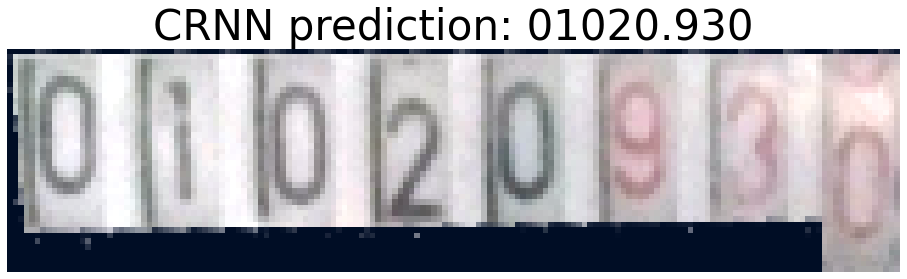

Image 8:
Greedy pred: 01020.930
Actual targ: 01020.930 


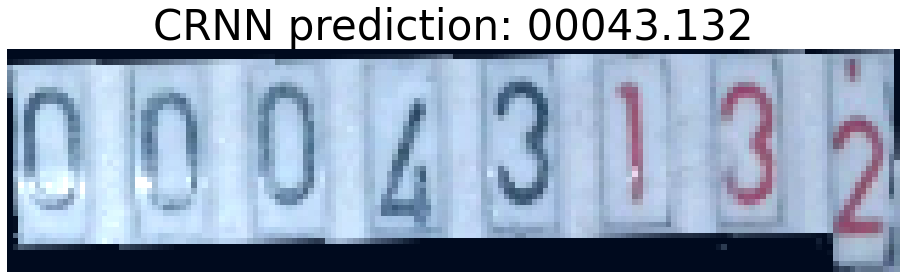

Image 9:
Greedy pred: 00043.132
Actual targ: 00043.132 


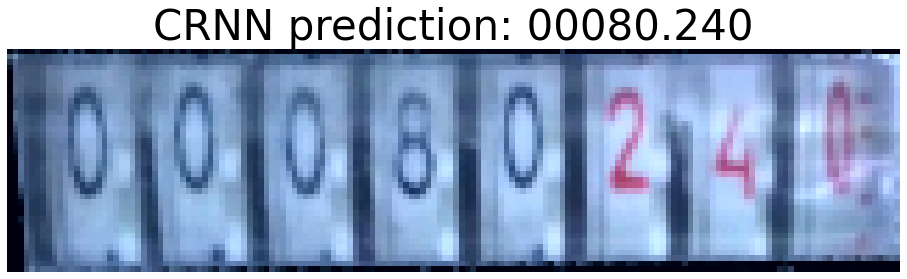

Image 10:
Greedy pred: 00080.240
Actual targ: 00080.240 


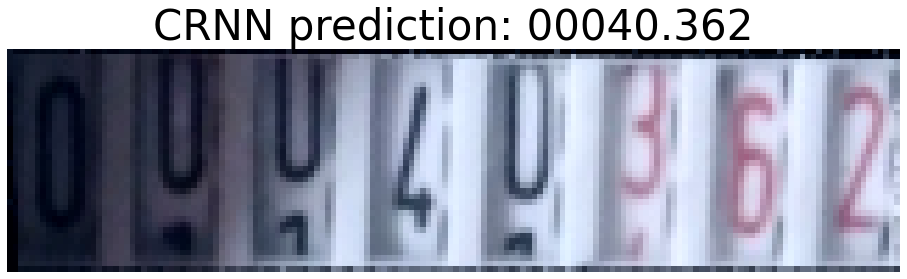

Image 11:
Greedy pred: 00040.362
Actual targ: 00040.362 


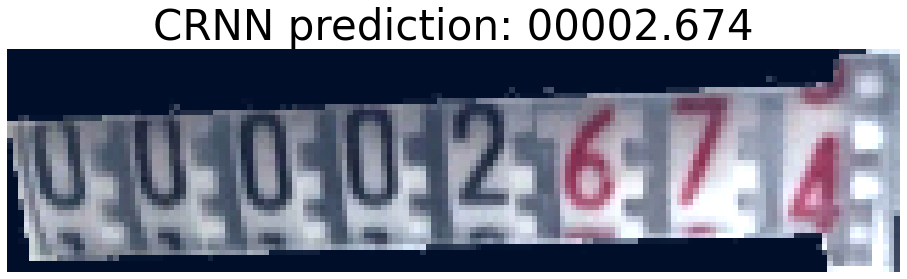

Image 12:
Greedy pred: 00002.674
Actual targ: 00002.674 


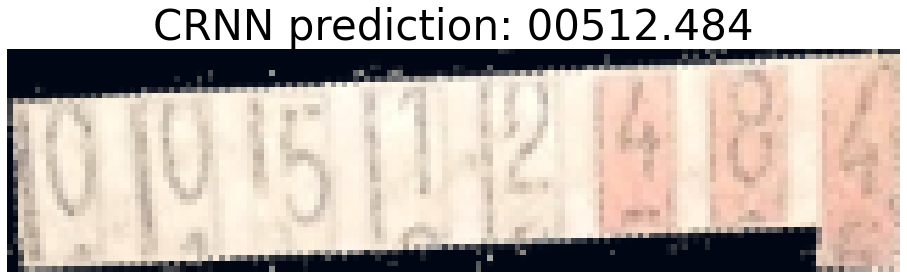

Image 13:
Greedy pred: 00512.484
Actual targ: 00512.484 


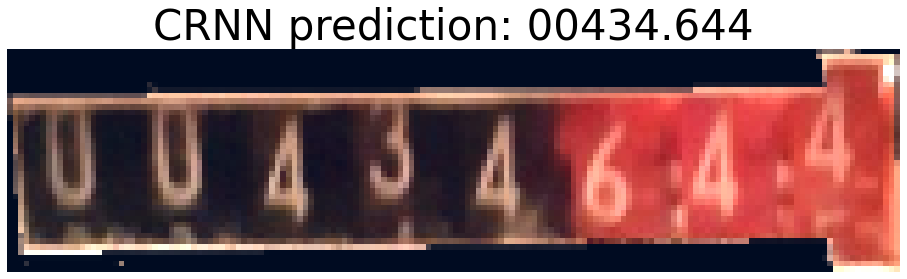

Image 14:
Greedy pred: 00434.644
Actual targ: 00434.644 


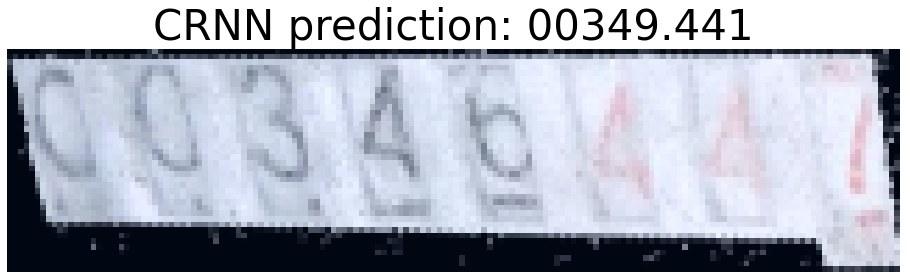

Image 15:
Greedy pred: 00349.441
Actual targ: 00346.447 


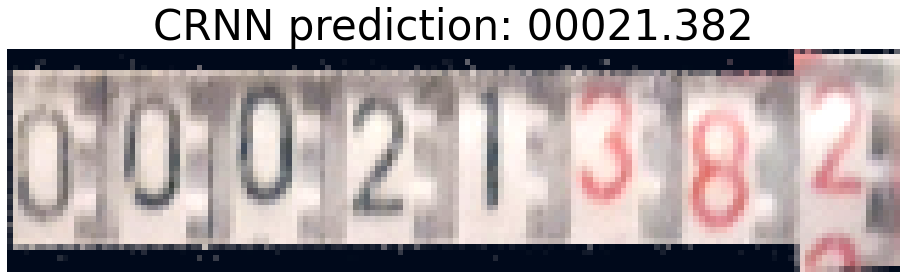

Image 16:
Greedy pred: 00021.382
Actual targ: 00021.382 


In [ ]:
with open(TABLE_path, 'r') as f:
    # with open(TABLE_wmn, 'r') as f:
    table = [char.strip() for char in f]

for i in range(len(inp)):
    idx = i

    
    
    decoder = Decoder(table)
    img = tf.expand_dims(inp[idx], 0)
    y_pred = model(img)
    y_pred = decoder.decode(y_pred, method='greedy')[0]
    y_target = decoder.decode(tar, from_pred=False) [idx]

    visualize(
        # image=inp[idx][..., 0]
        image= denormalize( inp[idx].numpy() )
        # , colormap='gray'
        , title=f'CRNN prediction: {y_pred}'
    )
    print(f"Image {i+1}:")
    print(f'Greedy pred: {y_pred}')
    print(f"Actual targ: {y_target} " )

In [ ]:
references = []
hypothesis = []
bleu = []
ctr, all_acc = 0, 0

for batch, (inp, tar) in enumerate(val_loader):
    for i in range(inp.shape[0]):
        img = tf.expand_dims(inp[i], 0)
        y_pred = model(img)
        y_pred = decoder.decode(y_pred, method='greedy')[0]
        y_target = decoder.decode(tar, from_pred=False) [i]

        references.append(y_target)
        hypothesis.append(y_pred)
        # weights = ( 1./5, 1./5, 1./5, 1./5, 1./5 )
        # weights = ( 1./3, 1./3, 1./3 )        
        # weights = ( 1./2, 1./2 )        
        weights = ( 1./4, 1./4, 1./4, 1./4 )        
        bleu.append( sentence_bleu([list( y_target)], list( y_pred ),  weights=weights, smoothing_function=smoothier().method1))
        if y_target.split(".")[0] == y_pred.split('.')[0]:
            ctr+=1
        if y_target == y_pred:
            all_acc+=1

print(f"Left acc: {(ctr/len(references) * 100):.4f} \tBLEU acc: {(np.mean(bleu) * 100):.4f} \tAll acc: {(all_acc/len(references)*100):.4f}")
# ctr/len(references) * 100  , np.mean(bleu) * 100

Left acc: 84.8485 	BLEU acc: 86.5985 	All acc: 67.2176


In [ ]:
# Left acc: 82.6446 	BLEU acc: 82.2240 	All acc: 51.2397 # best using all config
# Left acc: 82.36915 	BLEU acc: 83.69178 	All acc: 59.50413 # with .33 rotation and .667
# Left acc: 82.64463 	BLEU acc: 81.23256 	All acc: 47.93388
# Left acc: 79.61433 	BLEU acc: 78.91988 	All acc: 38.84298
# (82.84182305630027, 79.37915717161187)

In [ ]:
model.evaluate(val_loader)

24/24 [==============================] - 1s 24ms/step - loss: 5.5251 - word_accuracy: 0.3968


[5.5251007080078125, 0.39678284525871277]

# HPARAMS

In [ ]:
from tensorboard.plugins.hparams import api as hp

# HP_BATCH_SIZE = hp.HParam('batch_size', hp.Discrete([8, 16 , 24, 32]))
HP_BATCH_SIZE = hp.HParam('batch_size', hp.Discrete([16 , 32]))
# HP_LR_RATE = hp.HParam('lr_rate', hp.RealInterval(0.01, 0.1))
HP_LR_RATE = hp.HParam('lr_rate', hp.Discrete([ 0.0005 ,0.00075, 0.001 ])) # , 0.01]))
HP_ACTIVATION = hp.HParam('activation', hp.Discrete(['relu', 'swish'])) 

# METRIC_ACCURACY = 'seq-accuracy'

HPARAM_path = 'logs/hparam_tuning'
HPARAMS = [HP_BATCH_SIZE 
           , HP_LR_RATE
           , HP_ACTIVATION
            ]

METRICS = [hp.Metric("seq_accuracy", display_name='Seq Accuracy'),
        #    hp.Metric('seq_accuracy', group='train')
           ]


# with tf.summary.create_file_writer(HPARAM_path).as_default():
#   hp.hparams_config(
#     hparams=[HP_BATCH_SIZE], #, HP_DROPOUT, HP_OPTIMIZER],
#     metrics=[hp.Metric(METRIC_ACCURACY, display_name='Accuracy')],
#   )


In [ ]:
print('Path:', HPARAM_path)

def run(base_logdir, session_id, hparams):
    """Run a training/validation session.
    Flags must have been parsed for this function to behave.
    Args:
      base_logdir: The top-level logdir to which to write summary data.
      session_id: A unique string ID for this session.
      hparams: A dict mapping hyperparameters in `HPARAMS` to values.
    """
    model = build_model(num_classes=data_builder.num_classes.numpy(), shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)
                        # , hparams=hparams
                        ) 
    
    logdir = os.path.join(base_logdir, session_id)
    # dataloaders
    train_loader = data_builder.build(X_cut_train, y_train, hparams[HP_BATCH_SIZE], is_training=True)
    val_loader = data_builder.build(X_cut_valid, y_valid, hparams[HP_BATCH_SIZE], False)

    callback = tf.keras.callbacks.TensorBoard(
        logdir,
        profile_batch=0,  # workaround for issue #2084
    )
    hparams_callback = hp.KerasCallback(logdir, hparams) 
    callbacks = [callback, hparams_callback,
                 tf.keras.callbacks.ModelCheckpoint(
                '{}/{}_{}_best_model.h5'.format(logdir, model.name,
                                        'model')
                    , save_weights_only=True, save_best_only=True, mode='max'
                    , monitor='val_seq_accuracy')
                 , tf.keras.callbacks.EarlyStopping(
                        monitor='val_seq_accuracy', patience=15,
                        mode='max', restore_best_weights=True
                        )
                 
                ]
    # optimizer = tf.keras.optimizers.Adam(0.0005, clipnorm=CLIP_NORM)
    optimizer = tf.keras.optimizers.Adam(hparams[HP_LR_RATE], clipnorm=CLIP_NORM)

    model.compile(optimizer=optimizer,
                  loss=CTCLoss(),
                  metrics=[SequenceAccuracy(), EditDistance()]
                  )
    # training
    model.fit(train_loader, verbose=0, epochs=100, callbacks=callbacks,
                    validation_data=val_loader
                    )
    # loading best weights
    model.load_weights('{}/{}_{}_best_model.h5'.format(logdir, model.name,
                                        'model'))
    # pass over the valid set - plot those values
    loss, seq_acc, edit_dt = model.evaluate(val_loader)
    with tf.summary.create_file_writer(logdir).as_default():
        hp.hparams(hparams)  # record the values used in this trial
        # grab the last value of the pass
        # seq_acc = result.history['val_seq_accuracy'][-1]
        tf.summary.scalar('seq_accuracy', seq_acc, step=1)

Path: logs/hparam_tuning


In [ ]:
tf.keras.backend.clear_session()

def run_all(logdir, verbose=False):
    """Perform random search over the hyperparameter space.
    Arguments:
      logdir: The top-level directory into which to write data. This
        directory should be empty or nonexistent.
      verbose: If true, print out each run's name as it begins.
    """

    with tf.summary.create_file_writer(logdir).as_default():
        hp.hparams_config(hparams=HPARAMS, metrics=METRICS)
    
    sessions_per_group = 3
    num_session_groups = 1
    num_sessions = num_session_groups * sessions_per_group
    session_index = 0  # across all session groups
    # for group_index in range(num_session_groups):   # to have diff groups     
    for batch_sz in HP_BATCH_SIZE.domain.values:
        for lr_rate in HP_LR_RATE.domain.values:
            for act in HP_ACTIVATION.domain.values:
                hparams = {HP_BATCH_SIZE: batch_sz
                           , HP_LR_RATE: lr_rate
                           , HP_ACTIVATION: act
                           }
                for repeat_index in range(sessions_per_group): # to run several times same feature
                    session_id = f'run_{session_index}-{repeat_index}--{batch_sz}-{lr_rate}'
                    if verbose:
                        # print(f'---Running training session {session_index}/{num_sessions}')
                        print(f'---Running training: run-{session_index}')
                        print({h.name: hparams[h] for h in hparams})
                        print(f'--- repeat # {repeat_index + 1}')
                    run(
                        base_logdir=logdir,
                        session_id=session_id,
                        hparams=hparams,
                    )
                session_index += 1
                
run_all(HPARAM_path, verbose=True)


---Running training: run-0
{'batch_size': 16, 'lr_rate': 0.0005, 'activation': 'relu'}
--- repeat # 1
23/23 [==============================] - 1s 22ms/step - loss: 5.0055 - seq_accuracy: 0.5344 - edit_distance: 0.1047
---Running training: run-0
{'batch_size': 16, 'lr_rate': 0.0005, 'activation': 'relu'}
--- repeat # 2
23/23 [==============================] - 1s 22ms/step - loss: 4.5892 - seq_accuracy: 0.5510 - edit_distance: 0.0995
---Running training: run-0
{'batch_size': 16, 'lr_rate': 0.0005, 'activation': 'relu'}
--- repeat # 3
23/23 [==============================] - 1s 22ms/step - loss: 4.6388 - seq_accuracy: 0.5455 - edit_distance: 0.0961
---Running training: run-1
{'batch_size': 16, 'lr_rate': 0.0005, 'activation': 'swish'}
--- repeat # 1
23/23 [==============================] - 1s 21ms/step - loss: 4.4366 - seq_accuracy: 0.5647 - edit_distance: 0.0937
---Running training: run-1
{'batch_size': 16, 'lr_rate': 0.0005, 'activation': 'swish'}
--- repeat # 2
23/23 [=================

In [ ]:
# !rm -r logs/

In [ ]:
# Load the TensorBoard notebook extension.
%reload_ext  tensorboard
%tensorboard --logdir logs/hparam_tuning

In [ ]:
# !ps ax | grep tensorboard # tensorboard --logdir logs/hparam_tuning
# !kill 10390    

  11346 ?        S      0:00 /bin/bash -c ps ax | grep tensorboard # tensorboard --logdir logs/hparam_tuning
  11348 ?        S      0:00 grep tensorboard


# Weights

In [ ]:
!ls "{weights_dir}"
!ls "{loading_dir}"

CRNN_model  seq_num_detector_tf_float16.tflite
logs_CRNN   seq_num_detector_tf_float32.tflite
ls: cannot access './CRNN_model/': No such file or directory


## Saving weights

- Copying files from Colab to DRIVE

In [ ]:
!cp -vr CRNN_model "{weights_dir}"
!cp -vr logs_CRNN "{weights_dir}"

'CRNN_model/CRNN_model_best_model.h5' -> 'drive/My Drive/NRB_project/CRNN/CRNN_model/CRNN_model_best_model.h5'
'CRNN_model/CRNN_model_loss_model.h5' -> 'drive/My Drive/NRB_project/CRNN/CRNN_model/CRNN_model_loss_model.h5'
'logs_CRNN/train/events.out.tfevents.1617063098.ac6c5608d1e6.61.556977.v2' -> 'drive/My Drive/NRB_project/CRNN/logs_CRNN/train/events.out.tfevents.1617063098.ac6c5608d1e6.61.556977.v2'
'logs_CRNN/validation/events.out.tfevents.1617063105.ac6c5608d1e6.61.563887.v2' -> 'drive/My Drive/NRB_project/CRNN/logs_CRNN/validation/events.out.tfevents.1617063105.ac6c5608d1e6.61.563887.v2'


## Loading weights

- Copying files from Drive to COLAB

In [ ]:
!cp -vr "{weights_dir}/." ./
!ls

'drive/My Drive/NRB_project/CRNN/./CRNN_model/CRNN_model_best_model.h5' -> '././CRNN_model/CRNN_model_best_model.h5'
'drive/My Drive/NRB_project/CRNN/./logs_CRNN' -> '././logs_CRNN'
'drive/My Drive/NRB_project/CRNN/./logs_CRNN/train' -> '././logs_CRNN/train'
'drive/My Drive/NRB_project/CRNN/./logs_CRNN/train/events.out.tfevents.1610687629.0575d52ecb0f.10715.1067.v2' -> '././logs_CRNN/train/events.out.tfevents.1610687629.0575d52ecb0f.10715.1067.v2'
'drive/My Drive/NRB_project/CRNN/./logs_CRNN/validation' -> '././logs_CRNN/validation'
'drive/My Drive/NRB_project/CRNN/./logs_CRNN/validation/events.out.tfevents.1610687636.0575d52ecb0f.10715.5200.v2' -> '././logs_CRNN/validation/events.out.tfevents.1610687636.0575d52ecb0f.10715.5200.v2'
checkpoints  CRNN_model  data  drive  logs_CRNN  sample_data


In [ ]:
model.built = True
model.load_weights('{}/{}_{}_best_model.h5'.format(loading_dir, model.name,
                                        'model'))

# Port to Tensorflow Lite

In [ ]:
table = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '.', '<BLK>']
blank_idx = len(table) -1
def map2string(inputs):
    """Map outputs to number sequence."""
    strings = []
    for i in inputs:
        text = [table[char_index] for char_index in i 
                if char_index != blank_idx]
        strings.append(''.join(text))
    return strings[0]

In [ ]:
prediction_model = tf.keras.models.Model(inputs=model.input, outputs=CTCdecoder()(model.output))

In [ ]:
tf.saved_model.save(prediction_model, checks_dir)

!ls "{checks_dir}"

INFO:tensorflow:Assets written to: ./checkpoints/assets


INFO:tensorflow:Assets written to: ./checkpoints/assets


assets	saved_model.pb	variables


In [ ]:
converter = tf.lite.TFLiteConverter.from_saved_model(checks_dir)

In [ ]:
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_ops = [
        tf.lite.OpsSet.TFLITE_BUILTINS, # enable TensorFlow Lite ops.
        tf.lite.OpsSet.SELECT_TF_OPS # enable TensorFlow ops.
    ]

In [ ]:
# converter.target_spec.supported_types = [tf.float16]
# tf_lite_model = converter.convert()
# # saving the model
# open(f'crnn_detector_tf_float16.tflite', 'wb').write(tf_lite_model)
# ------------------------------------
converter.target_spec.supported_types = [tf.float32]
tf_lite_model = converter.convert()
# saving the model
open(f'crnn_detector_tf_float32.tflite', 'wb').write(tf_lite_model)

28654772

In [ ]:
!du -sh crnn_detector_tf_float32.tflite

28M	crnn_detector_tf_float32.tflite


Batch has 11 images.


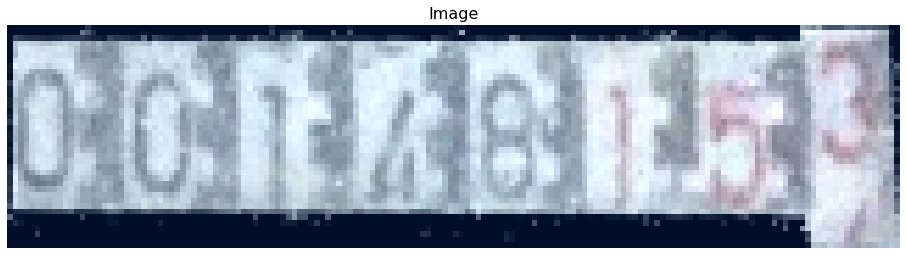

Image: 4; predicted sequence: 00148.153


In [ ]:
def infere_tf_lite_model(path, image):
    input_data = image

    interpreter = tf.lite.Interpreter(model_path=path)
    interpreter.allocate_tensors()

    # Get input and output tensors.
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    input_shape = input_details[0]['shape']
    interpreter.set_tensor(input_details[0]['index'], input_data)
    interpreter.invoke()

    output = interpreter.get_tensor(output_details[0]['index'])
    return output

#  grab image from valid dataset
print(f"Batch has {inp.shape[0]} images.")
idx = 4
image = np.expand_dims(inp[idx].numpy(), axis=0)
#  predict sequence-of-numbers
output = infere_tf_lite_model("crnn_detector_tf_float16.tflite", image=image)
# plots
visualize(
    image= denormalize(inp[idx].numpy())
)
print(f"Image: {idx}; predicted sequence: {map2string(output)}")

In [ ]:
# copy LITE model to DRIVE
!cp -vr crnn_detector_tf_float16.tflite "{weights_dir}"
!cp -vr crnn_detector_tf_float32.tflite "{weights_dir}"

'crnn_detector_tf_float16.tflite' -> 'drive/My Drive/NRB_project/CRNN/crnn_detector_tf_float16.tflite'
'crnn_detector_tf_float32.tflite' -> 'drive/My Drive/NRB_project/CRNN/crnn_detector_tf_float32.tflite'


# Test with predicted ROI

In [ ]:
def infere_tf_lite_model(path, image):
    input_data = image

    interpreter = tf.lite.Interpreter(model_path=path)
    interpreter.allocate_tensors()

    # Get input and output tensors.
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    input_shape = input_details[0]['shape']
    interpreter.set_tensor(input_details[0]['index'], input_data)
    interpreter.invoke()

    output = interpreter.get_tensor(output_details[0]['index'])
    return output

In [ ]:
tests = [f"image{n}.png" for n in range(1,6)]

tests = ["00883201372079_0.jpg", "02800000312555_0.jpg", "00882401101858_0.jpg", "00882401146713_0.jpg", "00883201360504_0.jpg" ]

test_set = []
for t in tests: # use funct inside data builder
    test, _ = data_builder._decode_img(t, label=None)
    test_set.append(test)

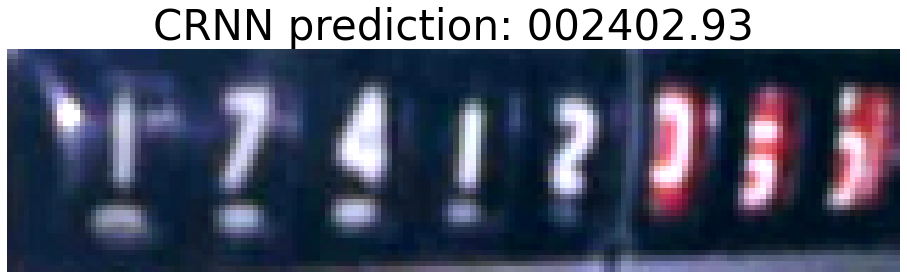

Predicted sequence: 002402.93


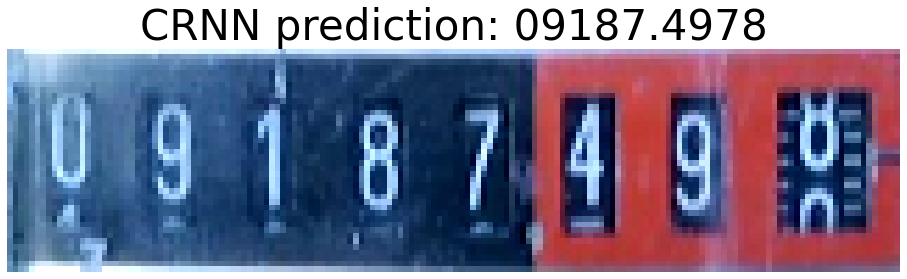

Predicted sequence: 09187.4978


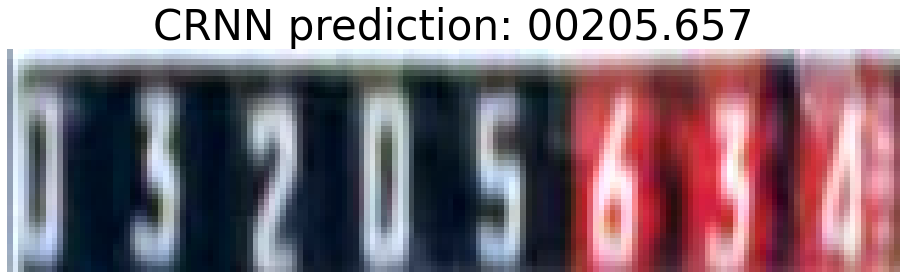

Predicted sequence: 00205.657


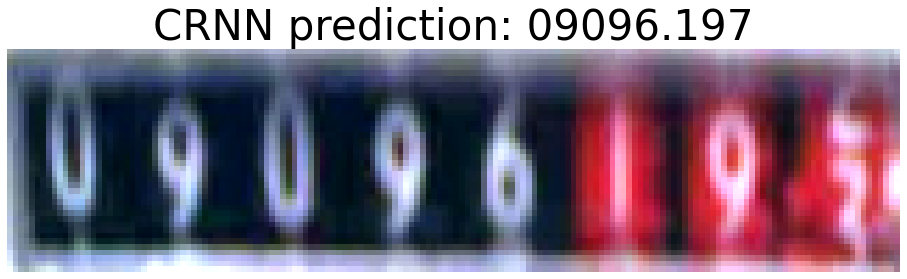

Predicted sequence: 09096.197


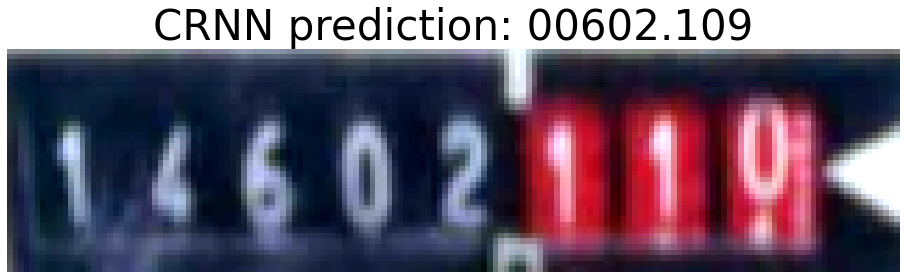

Predicted sequence: 00602.109


In [ ]:
for test in test_set:
    image = np.expand_dims(test.numpy(), axis=0)
    #  predict sequence-of-numbers
    output = infere_tf_lite_model("crnn_detector_tf_float16.tflite", image=image)
    # plots
    visualize(
        image= denormalize(image[0])
        , title=f'CRNN prediction: {map2string(output)}'
    )
    print(f"Predicted sequence: {map2string(output)}")

# useful info

Important, if want to create a model that implements everything:
- https://www.tensorflow.org/guide/keras/customizing_what_happens_in_fit

POSSIBLE FIXES
1. ~Maybe we can set two optimizers (encoder and decoder); possible two loss functs, need to check that. Smaller for encoder - bigger for decoder.~
2. ~Loss funct needs to be check~
3. ~Clipping the training variables, another technique to experiment~: Do it separetely?
4. ~Reducing complexity on the Augmentation techniques, might help.~ [DONE]
5. ~Scheduler might not work correctly.~ Check this: https://www.jeremyjordan.me/nn-learning-rate/
6. ~Bahdanau Att is desphased (old style) and needs to be change to Luong's att.~ [LUONG - NOT SOLVES THE PROBLEM]
7. ~Teacher-forcing might not be set.~



NB:
- Show, Attend and Tell: Neural Image Caption
Generation with Visual Attention [ https://arxiv.org/pdf/1502.03044.pdf ]
this article has good info related to the model. Check the loss function
- The chinese article, mentions that once the Image is cropped, then use a ConvNet to extract and decrease size of Images, then a Encoder-Decoder RNN: ==> encoder is bidirectional LSTM and decoder is a simply BAhduannaATT LSTM layer. No notice about the loss.
    - Normally Encoder-RNN is usually a Bidirectional layer.

# Model summary & graph model

In [ ]:
model.summary()

Model: "CRNN"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         [(None, 40, 160, 3)]      0         
_________________________________________________________________
conv1 (Conv2D)               (None, 40, 160, 64)       1792      
_________________________________________________________________
pool1 (MaxPooling2D)         (None, 20, 80, 64)        0         
_________________________________________________________________
conv2 (Conv2D)               (None, 20, 80, 128)       73856     
_________________________________________________________________
pool2 (MaxPooling2D)         (None, 10, 40, 128)       0         
_________________________________________________________________
conv3 (Conv2D)               (None, 10, 40, 256)       295168    
_________________________________________________________________
conv4 (Conv2D)               (None, 10, 40, 256)       590080 

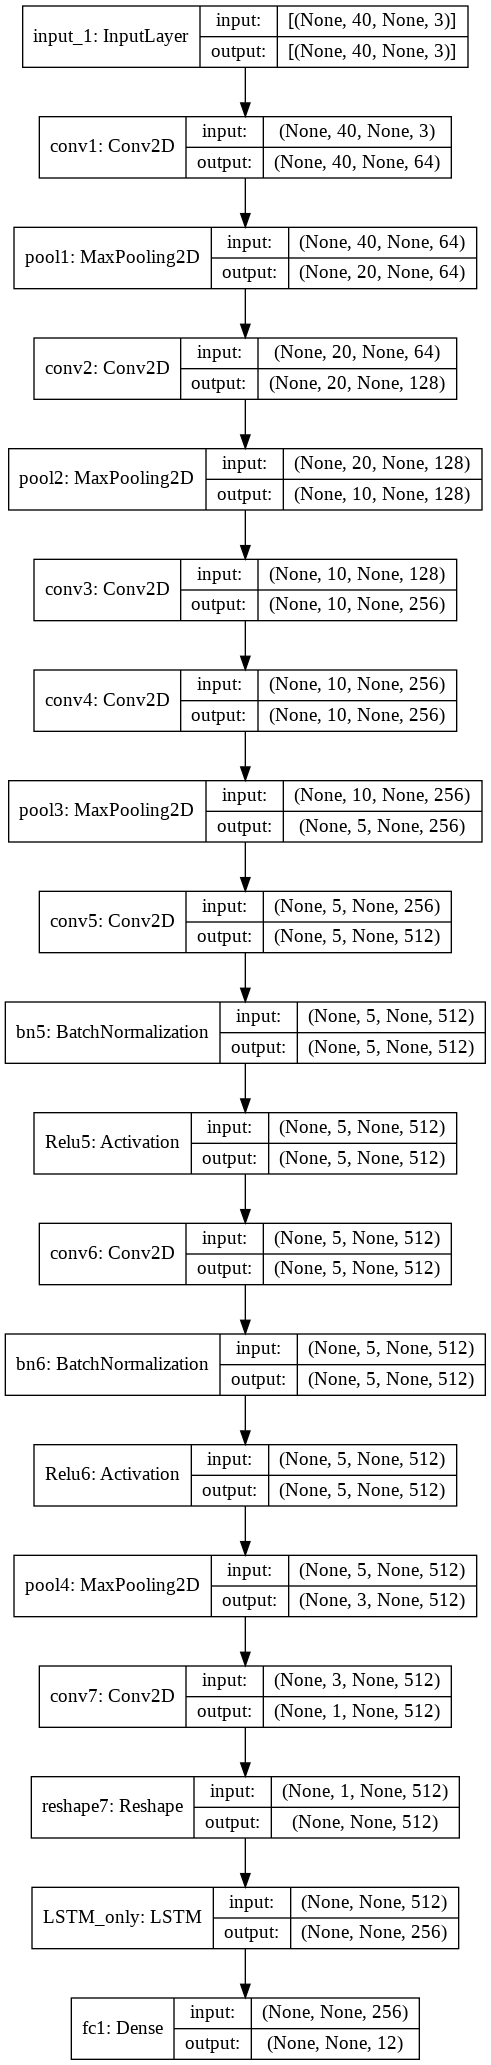

In [ ]:
tf.keras.utils.plot_model(model, show_shapes=True)

In [ ]:

# classes for data loading and preprocessing
class Dataset:
    """ Water-meter Dataset. Read images, 
        apply augmentation and preprocessing transformations.
    
    Args:
        images_dir (str): path to images folder
        masks_dir (str): path to segmentation masks folder
        augmentation (albumentations.Compose): data transfromation pipeline 
            (e.g. flip, scale, etc.)
        preprocessing (albumentations.Compose): data preprocessing 
            (e.g. noralization, shape manipulation, etc.)    
    """
    
    def __init__(
            self, 
            images_dir, 
            tar_masks_dir=None, 
            # classes=None, 
            augmentation=None, 
            preprocessing=None
            ):
        
        # self.ids = sorted(os.listdir(images_dir))
        self.ids = images_dir #os.listdir(images_dir)
        self.masks_ids = tar_masks_dir
        self.images_fps = [os.path.join(IMAGES_path, image_id) for image_id in self.ids]
        if isinstance(self.masks_ids, str):
            self.masks_fps = [os.path.join(tar_masks_dir, image_id) for image_id in self.ids]
        else:
            self.targets = tar_masks_dir
        # convert str names to class values on masks
        # self.class_values = [self.CLASSES.index(cls.lower()) for cls in classes]
        
        self.augmentation = augmentation
        self.preprocessing = preprocessing
        self.dim = (360, 480)
    
    def __getitem__(self, i):
        
        # read data
        image = cv2.imread(self.images_fps[i])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, self.dim, interpolation=cv2.INTER_NEAREST) # resizing
        # plt.figure(figsize=(16, 10))
        # plt.axis(False)
        # plt.imshow(image)
        # # testing
        # print('path:', self.images_fps[i])
        # cv2.imwrite("test1.png", cv2.cvtColor(image, cv2.COLOR_RGB2BGR))
        if isinstance(self.masks_ids, str):
            mask = cv2.imread(self.masks_fps[i], 0) # 0 = cv2.COLOR_GRAYSCALE
            mask = cv2.resize(mask, self.dim, interpolation=cv2.INTER_NEAREST) # resizing  
            # print(mask.shape)
            mask = np.array(mask).astype('float')
            # extract certain classes from mask (e.g. cars)
            # masks = [(mask == v) for v in self.class_values]
            # mask = np.stack(masks, axis=-1).astype('float')
            
            # add background if mask is not binary
            # if mask.shape[-1] != 1:
            #     print('it is not bin')
            #     print(mask.shape, mask.shape[-1], mask.max(), mask.min())
            #     background = 1 - mask.sum(axis=-1, keepdims=True)
            #     mask = np.concatenate((mask, background), axis=-1)
        
            # apply augmentations
            if self.augmentation:
                sample = self.augmentation(image=image, mask=mask)
                image, mask = sample['image'], sample['mask']
            
            # apply preprocessing
            if self.preprocessing:
                sample = self.preprocessing(image=image, mask=mask)
                image, mask = sample['image'], sample['mask']
                
            return image, mask
        else:
            target = self.targets[i]
            if self.augmentation:
                sample = self.augmentation(image=image)
                image = sample['image']
            if self.preprocessing:
                sample = self.preprocessing(image=image)
                image = sample['image']            
            return image, target
        
    def __len__(self):
        return len(self.ids)

# class Dataloader(tf.keras.utils.Sequence):
#     """Load data from dataset and form batches
    
#     Args:
#         dataset: instance of Dataset class for image loading and preprocessing.
#         batch_size: Integet number of images in batch.
#         shuffle: Boolean, if `True` shuffle image indexes each epoch.
#     """
    
#     def __init__(self, dataset, batch_size=1, shuffle=False):
#         self.dataset = dataset
#         self.batch_size = batch_size
#         self.shuffle = shuffle
#         self.indexes = np.arange(len(dataset))

#         self.on_epoch_end()

#     def __getitem__(self, i):
        
#         # collect batch data
#         start = i * self.batch_size
#         stop = (i + 1) * self.batch_size
#         data = []
#         for j in range(start, stop):
#             data.append(self.dataset[j])
        
#         # transpose list of lists
#         batch = [np.stack(samples, axis=0) for samples in zip(*data)]
#         return tuple(batch)
    
#     def __len__(self):
#         """Denotes the number of batches per epoch"""
#         return len(self.indexes) // self.batch_size
    
#     def on_epoch_end(self):
#         """Callback function to shuffle indexes each epoch"""
#         if self.shuffle:
#             self.indexes = np.random.permutation(self.indexes)